# Análisis de Datos — Trabajo Práctico Integrador
## Dataset: UCDP Georeferenced Event Dataset (GED) v25.1
### FIUBA - CEIA — 1B 2026

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('./GEDEvent_v25_1.csv', low_memory=False)
print(f'Dataset cargado correctamente: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado correctamente: 385,918 filas x 49 columnas


---
## 1. Exploración y Comprensión de los Datos

### 1.1 Características principales del dataset

In [141]:
print('=' * 60)
print(f'Observaciones : {df.shape[0]:,}')
print(f'Variables      : {df.shape[1]}')
print('=' * 60)
print()
print('Tipos de datos:')
print(df.dtypes.value_counts().to_string())
print()
print('Primeras filas:')
df.head(3)

Observaciones : 385,918
Variables      : 49

Tipos de datos:
int64      24
str        21
float64     3
bool        1

Primeras filas:


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN


In [142]:
# Descripcion de columnas relevantes
descripcion = {
    'id'                : 'Identificador unico del evento',
    'year'              : 'Año del evento',
    'type_of_violence'  : 'Tipo de violencia: 1=Estado vs Estado, 2=No-estatal, 3=Unilateral',
    'conflict_name'     : 'Nombre del conflicto',
    'side_a / side_b'   : 'Actores enfrentados',
    'country'           : 'Pais donde ocurrio el evento',
    'region'            : 'Region geografica',
    'date_start/end'    : 'Fecha de inicio y fin del evento',
    'deaths_a'          : 'Muertes del actor A',
    'deaths_b'          : 'Muertes del actor B',
    'deaths_civilians'  : 'Muertes de civiles',
    'deaths_unknown'    : 'Muertes de origen desconocido',
    'best'              : 'Estimacion central de muertes totales',
    'high'              : 'Estimacion alta de muertes',
    'low'               : 'Estimacion baja de muertes',
    'latitude/longitude': 'Coordenadas geograficas del evento',
    'where_prec'        : 'Precision geografica (1=exacta, 7=pais)',
    'date_prec'         : 'Precision temporal (1=dia exacto, 5=año)',
    'event_clarity'     : 'Claridad del evento (1=confirmado, 2=posible)',
    'number_of_sources' : 'Cantidad de fuentes que reportan el evento',
}

print('Descripcion de variables principales:')
print('-' * 60)
for col, desc in descripcion.items():
    print(f'  {col:<22} {desc}')

Descripcion de variables principales:
------------------------------------------------------------
  id                     Identificador unico del evento
  year                   Año del evento
  type_of_violence       Tipo de violencia: 1=Estado vs Estado, 2=No-estatal, 3=Unilateral
  conflict_name          Nombre del conflicto
  side_a / side_b        Actores enfrentados
  country                Pais donde ocurrio el evento
  region                 Region geografica
  date_start/end         Fecha de inicio y fin del evento
  deaths_a               Muertes del actor A
  deaths_b               Muertes del actor B
  deaths_civilians       Muertes de civiles
  deaths_unknown         Muertes de origen desconocido
  best                   Estimacion central de muertes totales
  high                   Estimacion alta de muertes
  low                    Estimacion baja de muertes
  latitude/longitude     Coordenadas geograficas del evento
  where_prec             Precision geografica (1=exa

In [143]:
# Estadisticas descriptivas de variables numericas clave
cols_numericas = ['year', 'best', 'high', 'low',
                  'deaths_a', 'deaths_b', 'deaths_civilians',
                  'deaths_unknown', 'number_of_sources']
df[cols_numericas].describe().round(2)

,year,best,high,low,deaths_a,deaths_b,deaths_civilians,deaths_unknown,number_of_sources
count,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00
mean,2012.49,10.25,15.12,8.54,2.47,2.25,3.82,1.72,0.82
std,9.41,347.68,426.86,313.66,254.72,53.76,178.40,99.62,1.65
min,1989.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00
25%,2007.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,-1.00
50%,2014.00,2.00,2.00,2.00,0.00,0.00,0.00,0.00,1.00
75%,2020.00,4.00,5.00,4.00,0.00,1.00,1.00,0.00,1.00
max,2024.00,121848.00,121848.00,121848.00,121848.00,19874.00,40000.00,48183.00,361.00


In [144]:
# Estadisticas descriptivas de variables categoricas
df.describe(include='object').T

,count,unique,top,freq
relid,385918,385918,IRQ-2017-1-524-322,1
code_status,385918,1,Clear,385918
conflict_name,385918,1529,Syria: Government,66186
dyad_name,385918,1771,Government of Syria - Syrian insurgents,66186
side_a,385918,966,Government of Syria,75181
side_b,385918,959,Syrian insurgents,66186
source_article,385917,255147,"""Balkan Battlegrounds: A Military History of t...",4123
source_office,288005,24027,SOHR,29640
source_date,288005,48785,2002-11-01;2012-11-01,5410
source_headline,288000,185443,Volume I and II;Bosnian Book of the Dead,4127


### 1.1.1 Verificaciones de integridad del dataset

A partir del codebook oficial (UCDP GED v25.1), se realizan las siguientes
verificaciones de consistencia interna del dataset.

In [145]:
# --- Verificacion 1: best == deaths_a + deaths_b + deaths_civilians + deaths_unknown ---
# Segun el codebook, best es SIEMPRE la suma exacta de los cuatro componentes
df['best_calculado'] = (df['deaths_a'] + df['deaths_b'] +
                        df['deaths_civilians'] + df['deaths_unknown'])
discrepancias = (df['best'] != df['best_calculado']).sum()
print(f'Verificacion 1: best == suma de componentes')
print(f'  Discrepancias encontradas: {discrepancias}')
print(f'  {"OK: el dataset es consistente en este aspecto." if discrepancias == 0 else "ALERTA: hay inconsistencias en el dataset."}')
df = df.drop(columns=['best_calculado'])

# --- Verificacion 2: active_year no es constante ---
print(f'\nVerificacion 2: valores de active_year')
print(df['active_year'].value_counts())
print(f'  Nota: 1 = el conflicto supero el umbral de 25 muertes ese año.')
print(f'  Nota: 0 = el conflicto no supero el umbral ese año pero registro eventos.')

# --- Verificacion 3: eventos con best == 0 ---
# Segun el codebook, un evento requiere al menos 1 muerte en alguna estimacion
# Por lo tanto eventos con best == 0 pueden tener muertes en 'low' o 'high'
eventos_best0 = df[df['best'] == 0]
print(f'\nVerificacion 3: eventos con best == 0')
print(f'  Total: {len(eventos_best0):,} ({len(eventos_best0)/len(df)*100:.1f}%)')
print(f'  De estos, con high > 0: {(eventos_best0["high"] > 0).sum():,}')
print(f'  De estos, con low > 0 : {(eventos_best0["low"] > 0).sum():,}')
print(f'  Explicacion: best = 0 no significa ausencia de muertes, sino que la')
print(f'  estimacion central es cero aunque las estimaciones extremas no lo sean.')

Verificacion 1: best == suma de componentes
  Discrepancias encontradas: 0
  OK: el dataset es consistente en este aspecto.

Verificacion 2: valores de active_year
active_year
True     373463
False     12455
Name: count, dtype: int64
  Nota: 1 = el conflicto supero el umbral de 25 muertes ese año.
  Nota: 0 = el conflicto no supero el umbral ese año pero registro eventos.

Verificacion 3: eventos con best == 0
  Total: 30,021 (7.8%)
  De estos, con high > 0: 30,018
  De estos, con low > 0 : 26
  Explicacion: best = 0 no significa ausencia de muertes, sino que la
  estimacion central es cero aunque las estimaciones extremas no lo sean.


### 1.2 Patrones generales y distribuciones

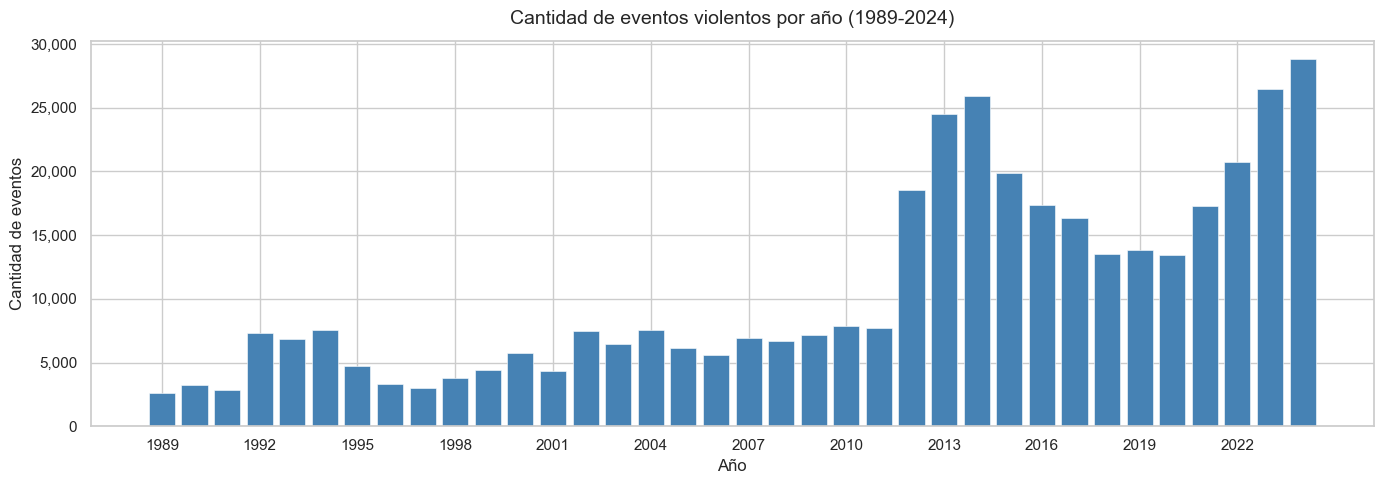

Año con mas eventos : 2024 (28,816 eventos)
Año con menos eventos: 1989 (2,624 eventos)


In [146]:
# --- Eventos por año ---
eventos_anio = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(eventos_anio.index, eventos_anio.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Cantidad de eventos violentos por año (1989-2024)', fontsize=14, pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de eventos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(1989, 2025, 3))
plt.tight_layout()
plt.show()

print(f'Año con mas eventos : {eventos_anio.idxmax()} ({eventos_anio.max():,} eventos)')
print(f'Año con menos eventos: {eventos_anio.idxmin()} ({eventos_anio.min():,} eventos)')

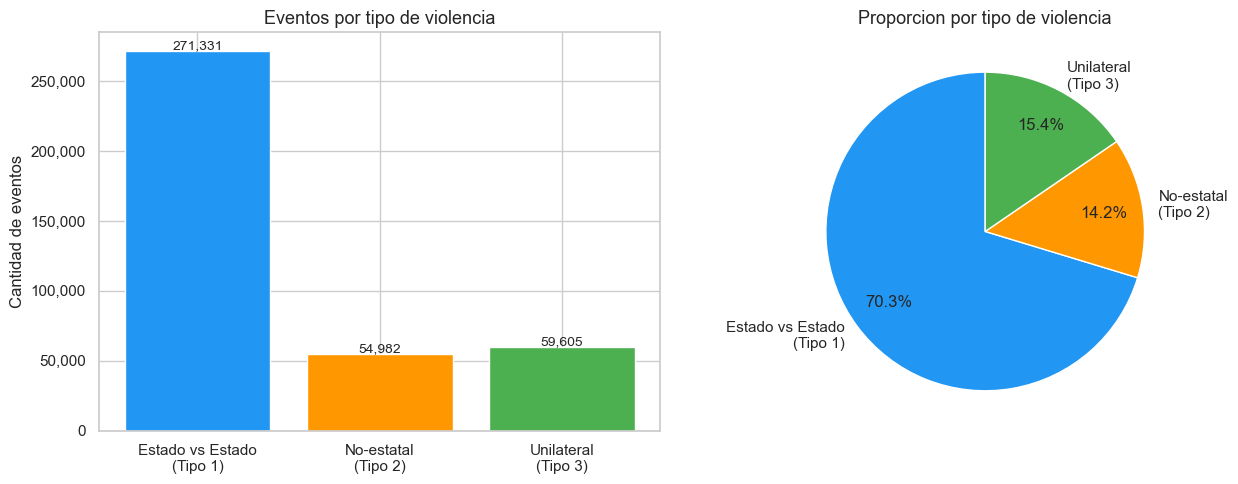

In [147]:
# --- Distribucion de tipo de violencia ---
tipo_labels = {1: 'Estado vs Estado\n(Tipo 1)',
               2: 'No-estatal\n(Tipo 2)',
               3: 'Unilateral\n(Tipo 3)'}
conteo_tipo = df['type_of_violence'].value_counts().sort_index()
conteo_tipo.index = [tipo_labels[i] for i in conteo_tipo.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(conteo_tipo.index, conteo_tipo.values,
            color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
axes[0].set_title('Eventos por tipo de violencia', fontsize=13)
axes[0].set_ylabel('Cantidad de eventos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(conteo_tipo.values):
    axes[0].text(i, v + 1500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(conteo_tipo.values, labels=conteo_tipo.index,
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800', '#4CAF50'],
            startangle=90, pctdistance=0.75)
axes[1].set_title('Proporcion por tipo de violencia', fontsize=13)

plt.tight_layout()
plt.show()

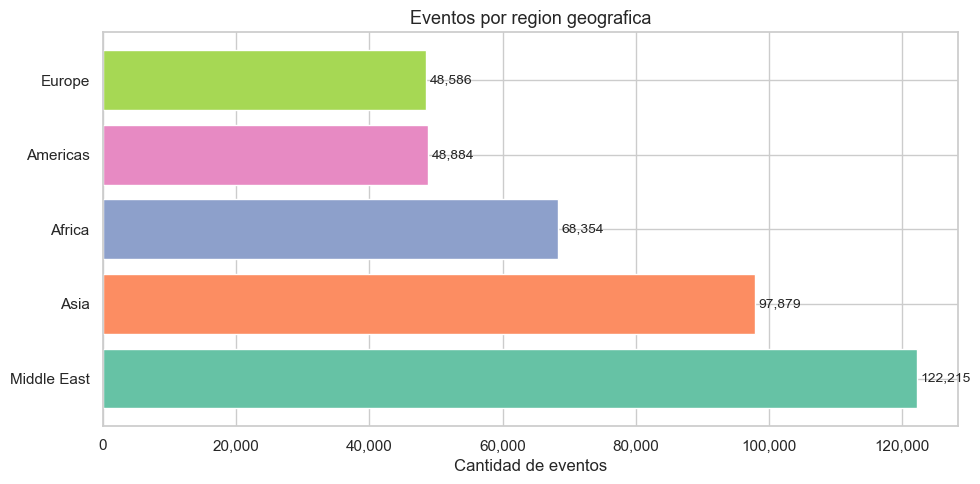

In [148]:
# --- Distribucion por region ---
conteo_region = df['region'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(conteo_region.index, conteo_region.values,
               color=sns.color_palette('Set2', len(conteo_region)))
ax.set_title('Eventos por region geografica', fontsize=13)
ax.set_xlabel('Cantidad de eventos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, conteo_region.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

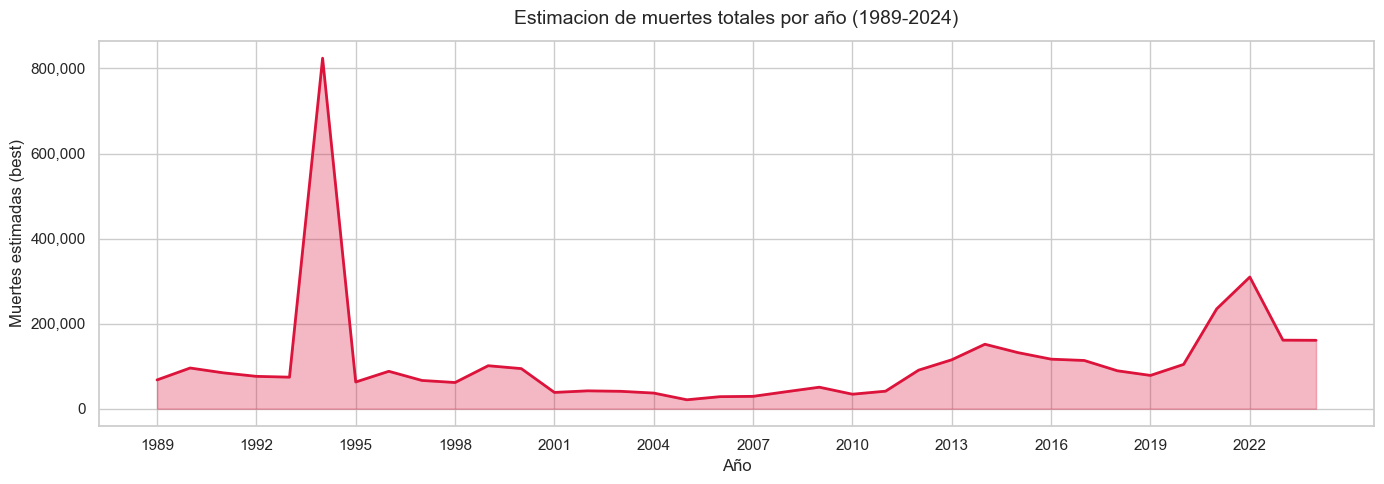

Año mas letal: 1994 (824,156 muertes estimadas)


In [149]:
# --- Muertes totales por año (estimacion 'best') ---
muertes_anio = df.groupby('year')['best'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(muertes_anio.index, muertes_anio.values, alpha=0.3, color='crimson')
ax.plot(muertes_anio.index, muertes_anio.values, color='crimson', linewidth=2)
ax.set_title('Estimacion de muertes totales por año (1989-2024)', fontsize=14, pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Muertes estimadas (best)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(1989, 2025, 3))
plt.tight_layout()
plt.show()

print(f'Año mas letal: {muertes_anio.idxmax()} ({muertes_anio.max():,.0f} muertes estimadas)')

#### Nota sobre el "Vague Number Translator"

El codebook del UCDP GED documenta un sistema estandarizado para convertir
lenguaje vago en números concretos de muertes. Por ejemplo:

| Expresión en fuente | Muertes asignadas |
|---|---|
| "a few" / "some" / "multiple" | 2 |
| "several" | 3 (best), 2 (low) |
| "dozens" | 24 |
| "scores" | 40 |
| "hundreds" | 200 |
| "thousands" | 2.000 |

Este sistema, implementado desde 2010, explica la presencia de **picos artificiales**
en valores como 2, 3, 24, 40, 200 y 2.000 en la distribución de `best`. No son
estimaciones precisas sino interpretaciones estandarizadas de lenguaje ambiguo en
las fuentes. Esto debe tenerse en cuenta al analizar la distribución de muertes y
al definir los umbrales de la variable `intensity`.

In [150]:
# --- Verificacion de picos en valores "vague number" ---
valores_vague = [2, 3, 24, 40, 200, 2000]

print('Frecuencia de valores asociados al Vague Number Translator:')
print('-' * 50)
for v in valores_vague:
    count = (df['best'] == v).sum()
    pct = count / len(df) * 100
    print(f'  best == {v:>5}: {count:>7,} eventos ({pct:.2f}%)')

print()
print('Comparacion con valores adyacentes (ejemplo para best == 24):')
for v in [22, 23, 24, 25, 26]:
    count = (df['best'] == v).sum()
    print(f'  best == {v}: {count:,}')
print('  El pico en 24 refleja la traduccion de "dozens" -> 24.')

Frecuencia de valores asociados al Vague Number Translator:
--------------------------------------------------
  best ==     2:  63,149 eventos (16.36%)
  best ==     3:  32,486 eventos (8.42%)
  best ==    24:     927 eventos (0.24%)
  best ==    40:     628 eventos (0.16%)
  best ==   200:     202 eventos (0.05%)
  best ==  2000:      24 eventos (0.01%)

Comparacion con valores adyacentes (ejemplo para best == 24):
  best == 22: 774
  best == 23: 737
  best == 24: 927
  best == 25: 905
  best == 26: 624
  El pico en 24 refleja la traduccion de "dozens" -> 24.


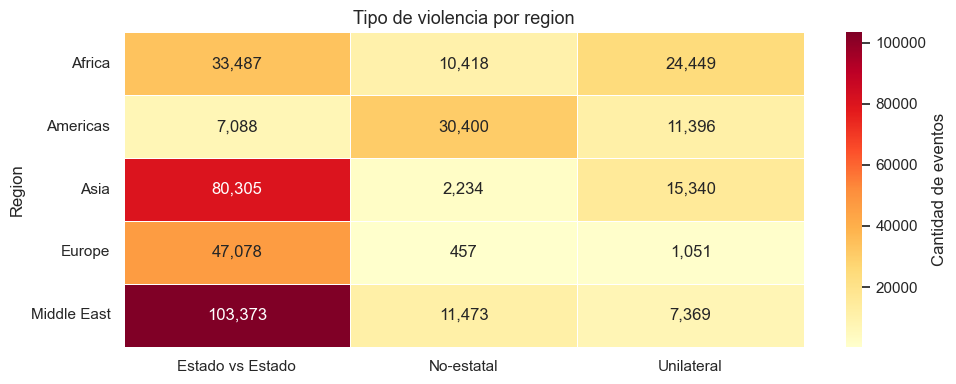

In [151]:
# --- Tipo de violencia por region (heatmap) ---
heatmap_data = df.groupby(['region', 'type_of_violence']).size().unstack(fill_value=0)
heatmap_data.columns = ['Estado vs Estado', 'No-estatal', 'Unilateral']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cantidad de eventos'})
ax.set_title('Tipo de violencia por region', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

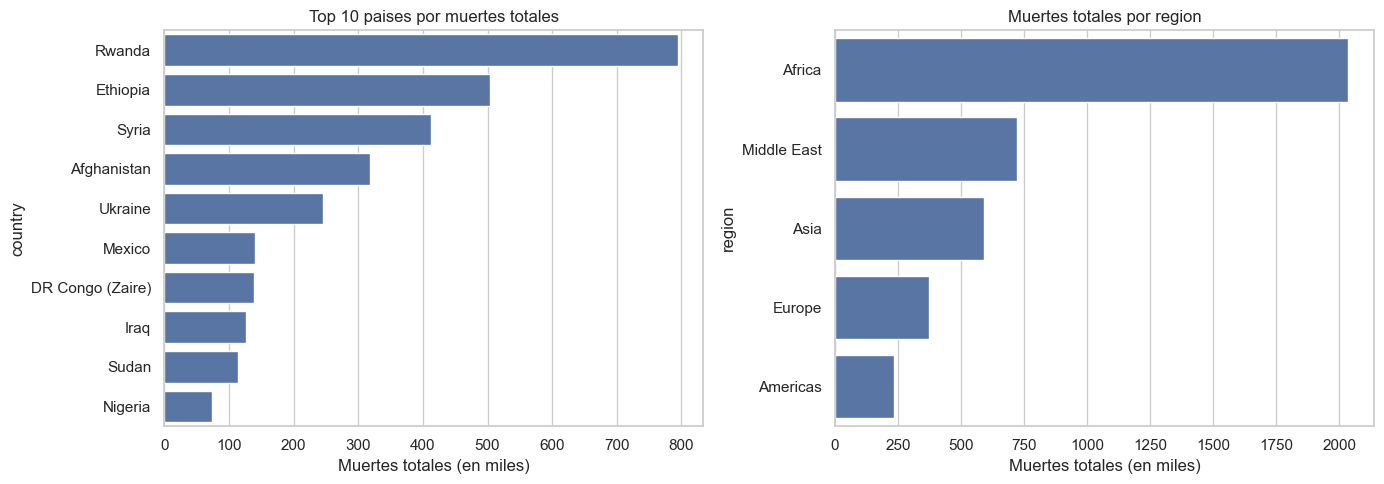

In [152]:
# --- Top 10 paises por muertes totales ---
top_paises = df.groupby('country')['best'].sum().sort_values(ascending=False).head(10)
top_regiones = df.groupby('region')['best'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_paises.values / 1000, y=top_paises.index, ax=axes[0])
axes[0].set_title('Top 10 paises por muertes totales', fontsize=12)
axes[0].set_xlabel('Muertes totales (en miles)')

sns.barplot(x=top_regiones.values / 1000, y=top_regiones.index, ax=axes[1])
axes[1].set_title('Muertes totales por region', fontsize=12)
axes[1].set_xlabel('Muertes totales (en miles)')

plt.tight_layout()
plt.show()

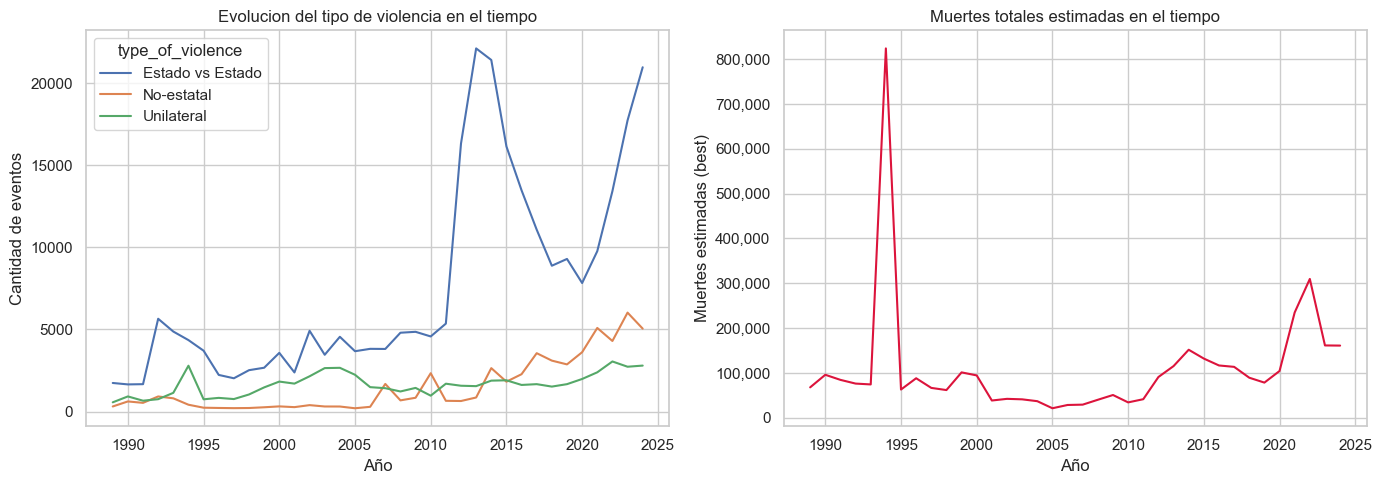

In [153]:
# --- Evolucion del tipo de violencia y muertes en el tiempo ---
violence_trend = df.groupby(['year', 'type_of_violence']).size().reset_index(name='count')
violence_trend['type_of_violence'] = violence_trend['type_of_violence'].map(
    {1: 'Estado vs Estado', 2: 'No-estatal', 3: 'Unilateral'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=violence_trend, x='year', y='count',
             hue='type_of_violence', ax=axes[0])
axes[0].set_title('Evolucion del tipo de violencia en el tiempo', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad de eventos')

deaths_trend = df.groupby('year')['best'].sum().reset_index()
sns.lineplot(data=deaths_trend, x='year', y='best', ax=axes[1], color='crimson')
axes[1].set_title('Muertes totales estimadas en el tiempo', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Muertes estimadas (best)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

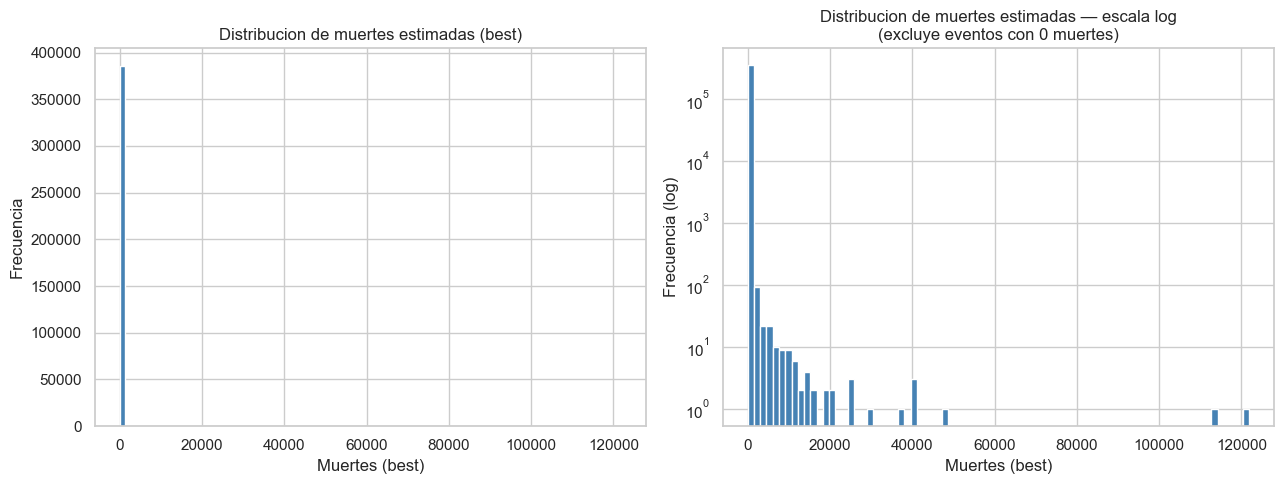

Eventos con 0 muertes registradas : 30,021 (7.8%)
Eventos con mas de 1000 muertes   : 264 (0.07%)


In [154]:
# --- Distribucion de muertes (best) ---
best_nonzero = df[df['best'] > 0]['best']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['best'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de muertes estimadas (best)', fontsize=12)
axes[0].set_xlabel('Muertes (best)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(best_nonzero, bins=80, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Distribucion de muertes estimadas — escala log\n(excluye eventos con 0 muertes)', fontsize=12)
axes[1].set_xlabel('Muertes (best)')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

print(f'Eventos con 0 muertes registradas : {(df["best"] == 0).sum():,} ({(df["best"] == 0).mean()*100:.1f}%)')
print(f'Eventos con mas de 1000 muertes   : {(df["best"] > 1000).sum():,} ({(df["best"] > 1000).mean()*100:.2f}%)')

### 1.3 Outliers

In [155]:
# --- Resumen de outliers por variable numerica ---
cols_numericas_out = ['best', 'high', 'low', 'deaths_a', 'deaths_b',
                      'deaths_civilians', 'deaths_unknown', 'number_of_sources']

resumen_outliers = []
for col in cols_numericas_out:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    n_out = (df[col] > lim_sup).sum()
    resumen_outliers.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3,
        'Limite superior': lim_sup,
        'Outliers': n_out,
        'Porcentaje (%)': round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(resumen_outliers).set_index('Variable')

,Q1,Q3,Limite superior,Outliers,Porcentaje (%)
Variable,,,,,
best,1.0,4.0,8.5,50210,13.01
high,1.0,5.0,11.0,45916,11.90
low,1.0,4.0,8.5,46614,12.08
deaths_a,0.0,0.0,0.0,94908,24.59
deaths_b,0.0,1.0,2.5,57128,14.80
deaths_civilians,0.0,1.0,2.5,40484,10.49
deaths_unknown,0.0,0.0,0.0,56401,14.61
number_of_sources,-1.0,1.0,4.0,5192,1.35


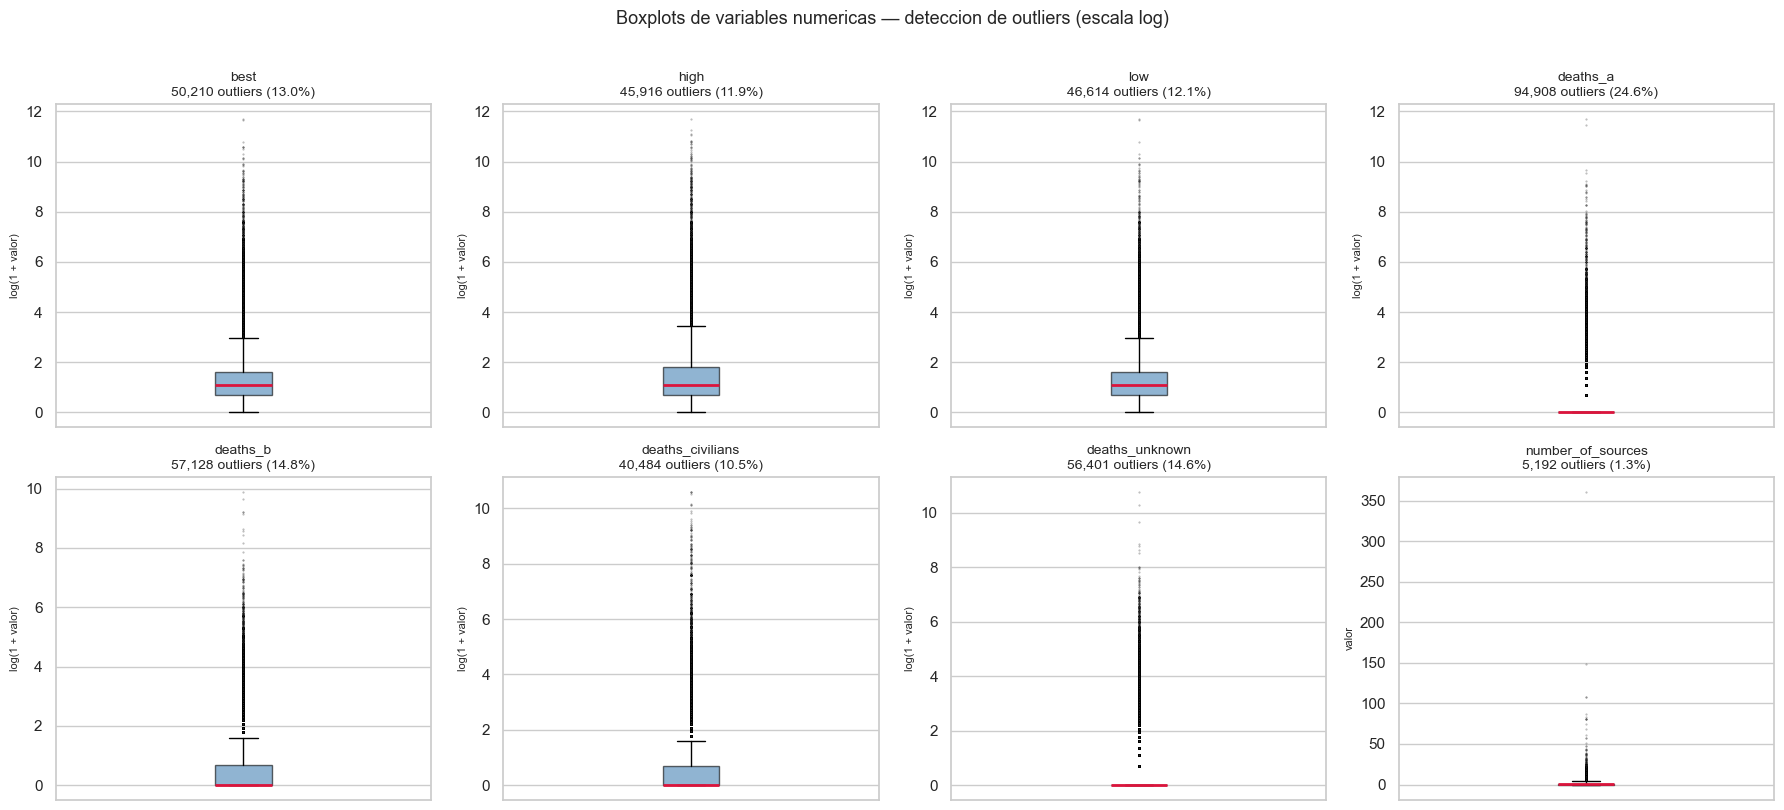

Nota: number_of_sources = -1 indica eventos sin fuente registrada (97,913 casos, 25.4% del total).
Estos valores son codificacion especial del dataset, no errores de carga.


In [156]:
# --- Boxplots de outliers por variable numerica (escala log) ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_numericas_out):
    datos = df[col].dropna()

    if col != 'number_of_sources':
        datos_plot = np.log1p(datos.clip(lower=0))
        ylabel = 'log(1 + valor)'
    else:
        datos_plot = datos
        ylabel = 'valor'

    Q1  = datos.quantile(0.25)
    Q3  = datos.quantile(0.75)
    IQR = Q3 - Q1
    lim = Q3 + 1.5 * IQR
    n_out = (datos > lim).sum()
    pct   = n_out / len(datos) * 100

    ax.boxplot(datos_plot, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='crimson', linewidth=2),
               flierprops=dict(marker='.', markersize=1,
                               markerfacecolor='gray', alpha=0.3))
    ax.set_title(f'{col}\n{n_out:,} outliers ({pct:.1f}%)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks([])

fig.suptitle('Boxplots de variables numericas — deteccion de outliers (escala log)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Nota: number_of_sources = -1 indica eventos sin fuente registrada',
      f'({(df["number_of_sources"] == -1).sum():,} casos, {(df["number_of_sources"] == -1).mean()*100:.1f}% del total).')
print('Estos valores son codificacion especial del dataset, no errores de carga.')

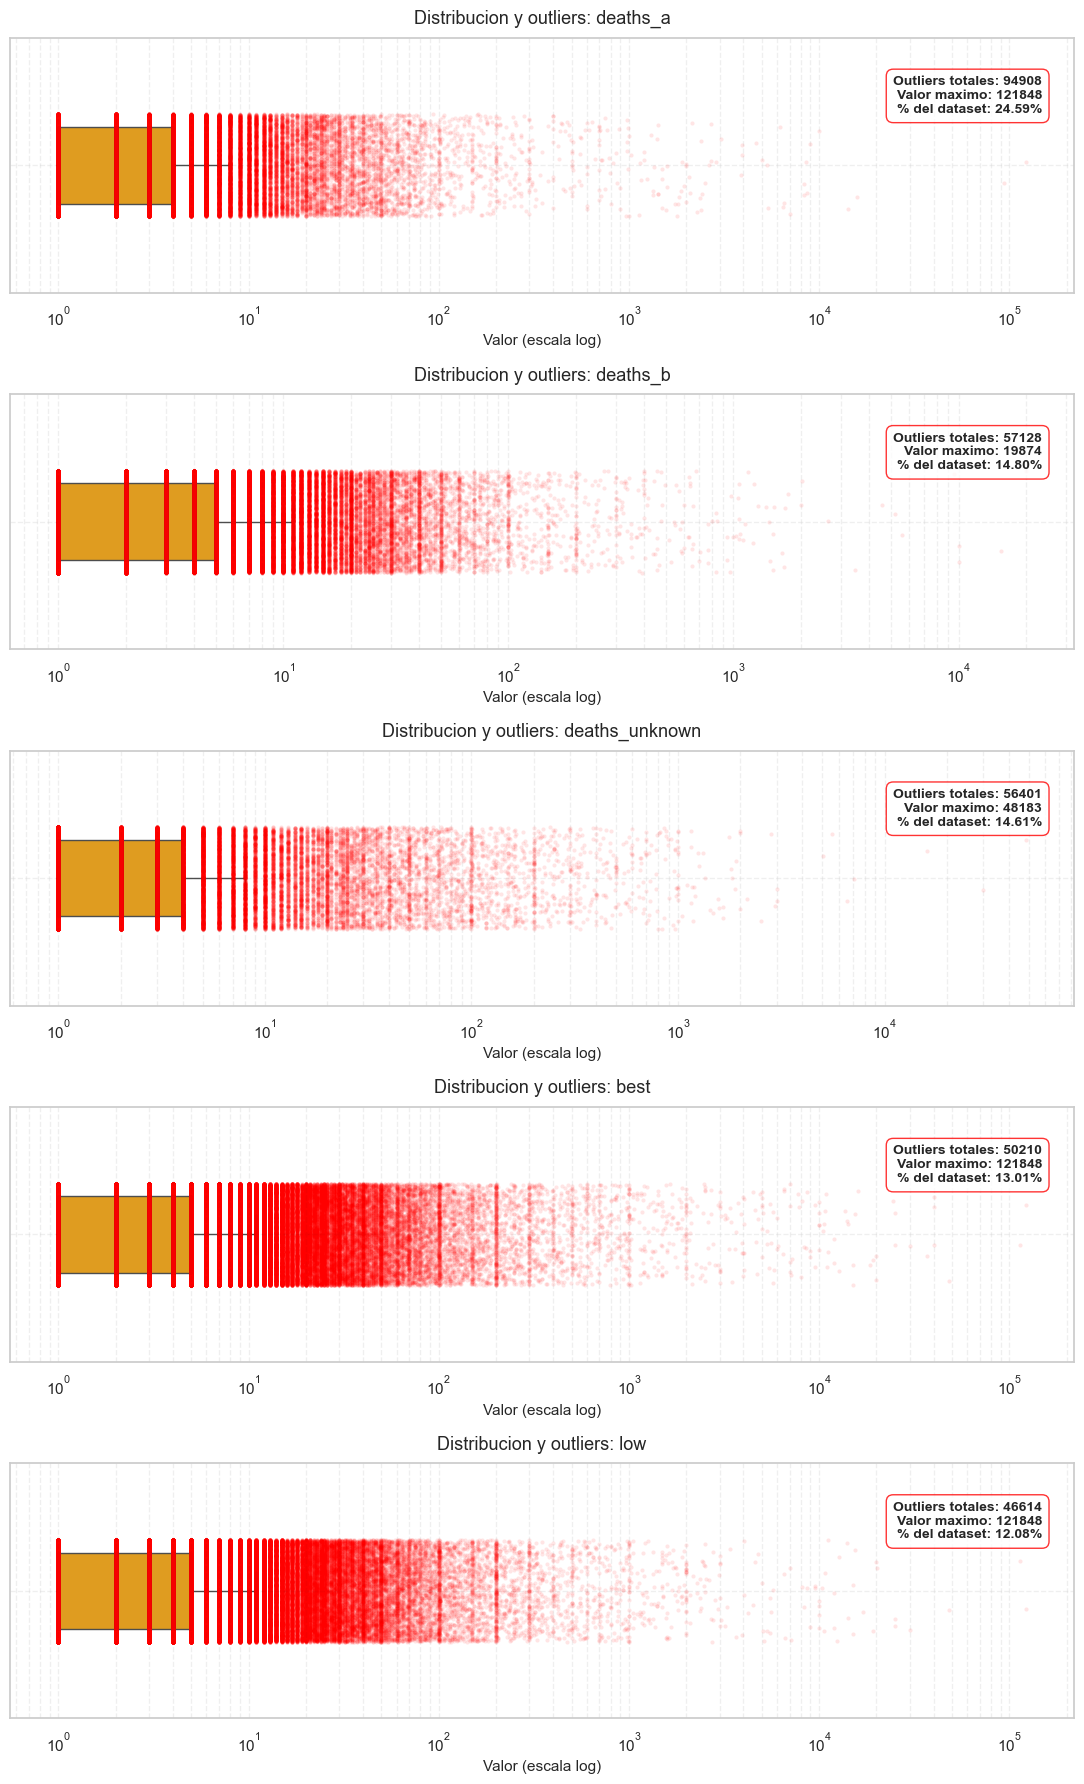

In [157]:
# --- Top 5 variables con mas outliers: boxplot + stripplot ---
df_num = df[cols_numericas_out].copy()
df_num = df_num.loc[:, ~df_num.columns.str.contains('id', case=False)]

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
outliers_mask = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))
outliers_pct = (outliers_mask.sum() / len(df_num) * 100).sort_values(ascending=False)
top5_cols = outliers_pct.head(5).index

fig, axes = plt.subplots(len(top5_cols), 1, figsize=(11, 18))

for i, col in enumerate(top5_cols):
    ax = axes[i]
    data_col = df_num[col].dropna()
    plot_data = data_col[data_col > 0]

    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1
    num_outliers = ((data_col < (q1 - 1.5 * iqr)) | (data_col > (q3 + 1.5 * iqr))).sum()
    max_val = data_col.max()
    perc_outliers = (num_outliers / len(data_col)) * 100

    sns.boxplot(x=plot_data, ax=ax, color='orange', width=0.3,
                flierprops={'marker': '', 'alpha': 0})
    sns.stripplot(x=plot_data, ax=ax, color='red', alpha=0.1, jitter=0.2, size=3)
    ax.set_xscale('log')
    ax.set_title(f'Distribucion y outliers: {col}', fontsize=13, pad=10)
    ax.set_xlabel('Valor (escala log)', fontsize=11)

    info_text = (f'Outliers totales: {num_outliers}\n'
                 f'Valor maximo: {max_val}\n'
                 f'% del dataset: {perc_outliers:.2f}%')
    ax.text(0.97, 0.85, info_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='red',
                      boxstyle='round,pad=0.5', alpha=0.8))
    ax.grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [158]:
# --- Top 10 eventos con mas muertes estimadas ---
print('Top 10 eventos mas letales:')
print(df[['year', 'country', 'conflict_name', 'type_of_violence', 'best']]
      .sort_values('best', ascending=False).head(10).to_string(index=False))

Top 10 eventos mas letales:
 year  country                    conflict_name  type_of_violence   best
 2022 Ethiopia             Ethiopia: Government                 1 121848
 2021 Ethiopia             Ethiopia: Government                 1 113368
 2000 Ethiopia               Eritrea - Ethiopia                 1  48183
 1994   Rwanda Government of Rwanda - Civilians                 3  40000
 1994   Rwanda Government of Rwanda - Civilians                 3  40000
 1994   Rwanda Government of Rwanda - Civilians                 3  40000
 1994   Rwanda Government of Rwanda - Civilians                 3  37000
 1999 Ethiopia               Eritrea - Ethiopia                 1  30000
 1994   Rwanda Government of Rwanda - Civilians                 3  25190
 1994   Rwanda Government of Rwanda - Civilians                 3  25000


### 1.4 Valores faltantes y su tipo (MCAR, MAR, MNAR)

In [159]:
# --- Resumen de valores faltantes ---
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print(resumen_nulos.to_string())

                    Nulos  Porcentaje (%)
gwnob              355662           92.16
source_headline     97918           25.37
source_date         97913           25.37
source_office       97913           25.37
gwnoa               93411           24.20
adm_2               69977           18.13
source_original     44244           11.46
adm_1               19547            5.07
where_description   10243            2.65
source_article          1            0.00


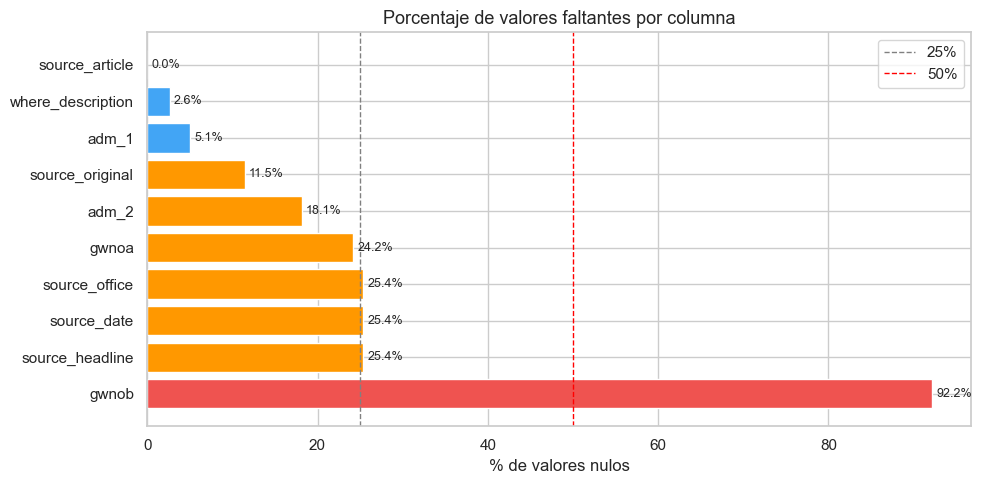

In [160]:
# --- Visualizacion de valores faltantes ---
fig, ax = plt.subplots(figsize=(10, 5))
cols_con_nulos = resumen_nulos.index.tolist()
pcts = resumen_nulos['Porcentaje (%)'].values

bars = ax.barh(cols_con_nulos, pcts,
               color=['#ef5350' if p > 50 else '#ff9800' if p > 10 else '#42a5f5' for p in pcts])
ax.set_title('Porcentaje de valores faltantes por columna', fontsize=13)
ax.set_xlabel('% de valores nulos')
ax.axvline(x=25, color='gray', linestyle='--', linewidth=1, label='25%')
ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='50%')
ax.legend()
for bar, val in zip(bars, pcts):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

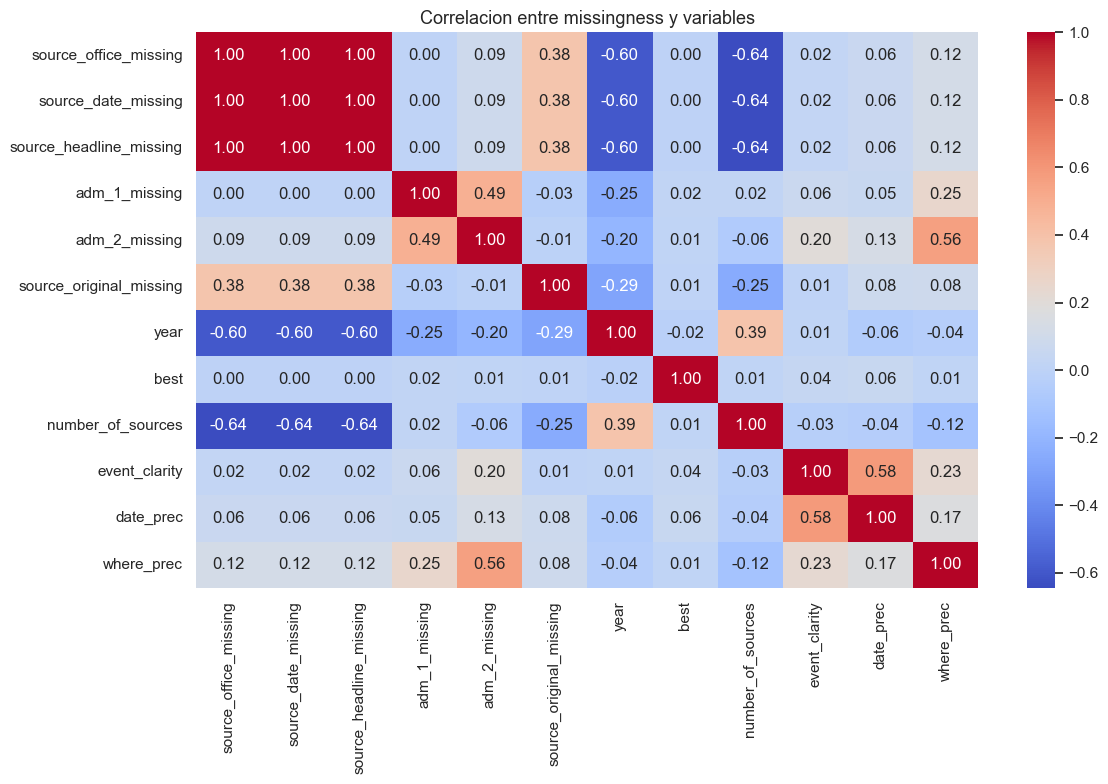

In [161]:
# --- Correlacion entre missingness y variables clave ---
df_miss = df.copy()
for col in ['source_office', 'source_date', 'source_headline', 'adm_1', 'adm_2', 'source_original']:
    df_miss[col + '_missing'] = df_miss[col].isnull().astype(int)

miss_cols = [c for c in df_miss.columns if c.endswith('_missing')]
cols_corr = miss_cols + ['year', 'best', 'number_of_sources', 'event_clarity', 'date_prec', 'where_prec']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_miss[cols_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax)
ax.set_title('Correlacion entre missingness y variables', fontsize=13)
plt.tight_layout()
plt.show()

In [162]:
# --- Clasificacion de valores faltantes ---
print('=== Clasificacion de valores faltantes ===')
print()
print('MCAR (Missing Completely At Random):')
print('  - source_article: solo 1 nulo, sin patron aparente')
print()
print('MAR (Missing At Random — dependen de otra variable observable):')
print('  - adm_1, adm_2: a mayor codigo de where_prec (menor precision),')
print('    hay mas nulos en subdivisiones administrativas')
print('  - source_office, source_date, source_headline: nulos correlacionados entre si,')
print('    solo disponibles para eventos posteriores a 2013')
print()
print('MNAR (Missing Not At Random — el valor faltante depende del propio valor):')
print('  - gwnob (92% nulos): solo tiene valor cuando el actor B es un Estado reconocido.')
print('    El dato falta porque la informacion no existe estructuralmente.')
print('  - source_original (11%): mas probable que falte cuando el evento fue')
print('    registrado con fuentes secundarias.')

print()
print('=== Verificacion MAR: nulos en adm_2 segun precision geografica ===')
nulos_adm2 = df.groupby('where_prec')['adm_2'].apply(
    lambda x: x.isnull().mean() * 100).round(1)
print(nulos_adm2.to_string())
print('(1=ubicacion exacta, 7=solo pais — a mayor codigo, mas nulos en adm_2)')

=== Clasificacion de valores faltantes ===

MCAR (Missing Completely At Random):
  - source_article: solo 1 nulo, sin patron aparente

MAR (Missing At Random — dependen de otra variable observable):
  - adm_1, adm_2: a mayor codigo de where_prec (menor precision),
    hay mas nulos en subdivisiones administrativas
  - source_office, source_date, source_headline: nulos correlacionados entre si,
    solo disponibles para eventos posteriores a 2013

MNAR (Missing Not At Random — el valor faltante depende del propio valor):
  - gwnob (92% nulos): solo tiene valor cuando el actor B es un Estado reconocido.
    El dato falta porque la informacion no existe estructuralmente.
  - source_original (11%): mas probable que falte cuando el evento fue
    registrado con fuentes secundarias.

=== Verificacion MAR: nulos en adm_2 segun precision geografica ===
where_prec
1      7.4
2      6.1
3      0.0
4    100.0
5     58.6
6    100.0
7     45.0
(1=ubicacion exacta, 7=solo pais — a mayor codigo, mas 

### 1.5 Resumen del EDA

| Aspecto | Hallazgo |
|---|---|
| Dimensiones | 385.918 eventos x 49 variables |
| Periodo | 1989-2024 |
| Tipo de violencia | Estado vs Estado es el mas frecuente (70.3%) |
| Region con mas eventos | Medio Oriente (31.7%) |
| Pais mas letal | Rwanda (~794.000 muertes, dominado por el genocidio de 1994) |
| Muertes | Distribucion muy sesgada a la derecha; mediana de 2 muertes por evento |
| Outliers | Detectados via IQR; outliers en variables de muertes son eventos reales, no errores |
| Valores faltantes | MCAR: source_article (1 caso) · MAR: adm_1, adm_2, fuentes · MNAR: gwnob (92%) |

## Conclusiones del EDA

El dataset UCDP GED v25.1 constituye un registro exhaustivo de eventos de violencia organizada a nivel global, abarcando **385.918 eventos entre 1989 y 2024**. El análisis exploratorio permitió identificar los siguientes hallazgos principales:

- **Dominancia del conflicto estatal**: el 70.3% de los eventos corresponden a violencia de tipo Estado vs Estado (Tipo 1), lo que refleja que la mayoría de los conflictos registrados involucran actores gubernamentales.
- **Concentración geográfica**: Medio Oriente y Asia concentran más del 57% de los eventos, con un aumento sostenido de registros desde mediados de los 2000, probablemente asociado a mejoras en la cobertura de fuentes y a la intensificación de conflictos en esas regiones.
- **Distribución de muertes fuertemente sesgada**: la variable `best` presenta una distribución con cola muy larga hacia la derecha. La mayoría de los eventos registran pocas muertes, pero existen outliers extremos (hasta 121.848 muertes en un único evento) que requieren un tratamiento cuidadoso en el preprocesamiento.
- **Valores faltantes con patrones diferenciados**: se identificaron tres tipos de missingness. Los nulos en `adm_2` y `adm_1` siguen un patrón MAR (dependen de la precisión geográfica del evento), mientras que `gwnob` presenta un claro caso MNAR ya que su ausencia refleja la inexistencia del dato (el actor B no es un Estado reconocido), y `source_article` presenta un único nulo que puede considerarse MCAR.
- **Calidad general aceptable**: las variables centrales del análisis (`type_of_violence`, `region`, `country`, `year`, `best`, coordenadas) no presentan valores faltantes, lo que garantiza una base sólida para el preprocesamiento y el modelado posterior.

---
## 2. Planteo del Problema de Machine Learning Supervisado

### 2.1 Descripción del problema

Se plantea un problema de **clasificación multiclase supervisada**.

El objetivo es predecir la **intensidad de un evento de violencia organizada** 
a partir de información contextual del mismo: dónde ocurrió, cuándo, quién fue 
el actor iniciador, con qué precisión fue registrado y cuántas fuentes lo reportaron.

Este problema tiene sentido real: ante un nuevo evento reportado, un modelo entrenado 
podría estimar automáticamente su nivel de letalidad, permitiendo a organismos de 
monitoreo de conflictos priorizar su respuesta y asignación de recursos.

### 2.2 Variable target

La variable target **`intensity`** se construye a partir de `best` 
(estimación central de muertes totales), discretizándola en 3 categorías:

| Clase | Etiqueta | Criterio | Cantidad | % |
|---|---|---|---|---|
| 0 | Baja | ≤ 5 muertes | 309.192 | 80.1% |
| 1 | Media | 6–20 muertes | 57.527 | 14.9% |
| 2 | Alta | > 20 muertes | 19.199 | 5.0% |

Los umbrales son **parametrizables** y pueden ajustarse según los resultados 
del análisis de balance de clases en el Paso 4.

⚠️ **Desbalance de clases**: la Clase 0 representa el 80% de los eventos. 
Esto deberá ser tratado en el paso de Feature Engineering mediante técnicas 
de balanceo (SMOTE, class weights, etc.).

> **Nota:** `intensity` se construye a partir de `best`, por lo que `best` y 
> todas las variables de muertes (`high`, `low`, `deaths_a`, `deaths_b`, 
> `deaths_civilians`, `deaths_unknown`) se excluyen como features para 
> evitar target leakage.

Umbrales -> Baja: <=5 | Media: 6-20 | Alta: >20

  Clase 0 (Baja): 309,192 (80.1%)
  Clase 1 (Media): 57,527 (14.9%)
  Clase 2 (Alta): 19,199 (5.0%)


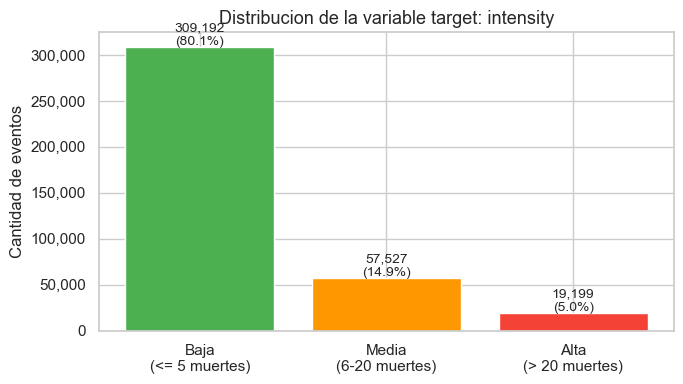

In [163]:
# --- Construccion del target 'intensity' ---

# Umbrales parametrizables
UMBRAL_BAJO  = 5    # muertes <= UMBRAL_BAJO  -> Clase 0 (Baja)
UMBRAL_MEDIO = 20   # muertes <= UMBRAL_MEDIO -> Clase 1 (Media)
                    # muertes >  UMBRAL_MEDIO -> Clase 2 (Alta)

def clasificar_intensidad(x, umbral_bajo=UMBRAL_BAJO, umbral_medio=UMBRAL_MEDIO):
    if x <= umbral_bajo:
        return 0
    elif x <= umbral_medio:
        return 1
    else:
        return 2

df['intensity'] = df['best'].apply(clasificar_intensidad)
df = df.drop(columns=['best'])

print(f'Umbrales -> Baja: <={UMBRAL_BAJO} | Media: {UMBRAL_BAJO+1}-{UMBRAL_MEDIO} | Alta: >{UMBRAL_MEDIO}')
print()
conteo = df['intensity'].value_counts().sort_index()
for val, cnt in conteo.items():
    etiqueta = {0: 'Baja', 1: 'Media', 2: 'Alta'}[val]
    print(f'  Clase {val} ({etiqueta}): {cnt:,} ({cnt/len(df)*100:.1f}%)')

# Visualizacion
fig, ax = plt.subplots(figsize=(7, 4))
etiquetas = ['Baja\n(<= 5 muertes)', 'Media\n(6-20 muertes)', 'Alta\n(> 20 muertes)']
ax.bar(etiquetas, conteo.values,
       color=['#4CAF50', '#FF9800', '#f44336'], edgecolor='white')
ax.set_title('Distribucion de la variable target: intensity', fontsize=13)
ax.set_ylabel('Cantidad de eventos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(conteo.values):
    ax.text(i, v + 2000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 Features seleccionados

Se excluyen las variables de muertes (`best`, `high`, `low`, `deaths_a`, `deaths_b`, 
`deaths_civilians`, `deaths_unknown`) para evitar **target leakage**, ya que el 
target `intensity` se deriva directamente de `best`.

A diferencia de lo que ocurriría si el target fuera `type_of_violence`, `side_b` 
**sí puede incluirse** como feature en este problema. Si bien en violencia unilateral 
siempre toma el valor "civilians", el análisis mostró que la intensidad media de los 
eventos es prácticamente igual entre eventos con `side_b = Civilians` (0.234) y sin 
él (0.251), por lo que no introduce leakage hacia el target `intensity`.

Se descartan además:
- **Identificadores internos** (`id`, `relid`, `conflict_dset_id`, `dyad_dset_id`, etc.): no aportan información semántica.
- **Redundancias geográficas** (`latitude`, `longitude`, `geom_wkt`, etc.): capturadas por `country` y `region`, aunque `adm_1` y `adm_2` se usarán mediante frequency encoding.
- **Texto libre y fuentes** (`source_article`, `source_headline`, `where_description`, etc.): requieren NLP y tienen muchos nulos.
- **Variable constante** (`code_status`, `active_year`): un único valor en todo el dataset.
- **Alta cardinalidad sin valor agregado** (`conflict_name`): redundante con `country` y `side_a`.

Los features finales seleccionados son:

| Feature | Tipo | Descripción |
|---|---|---|
| `region` | Categórica | Región geográfica del evento (one-hot encoding) |
| `country` | Categórica | País donde ocurrió (frequency encoding) |
| `year` | Numérica | Año del evento |
| `where_prec` | Ordinal | Precisión geográfica del registro (1=exacta, 7=país) |
| `date_prec` | Ordinal | Precisión temporal del registro (1=día exacto, 5=año) |
| `event_clarity` | Ordinal | Certeza del evento (1=confirmado, 2=posible) |
| `number_of_sources` | Numérica | Cantidad de fuentes que reportan el evento |
| `side_a` | Categórica | Actor iniciador de la violencia (frequency encoding) |
| `side_b` | Categórica | Actor receptor de la violencia (frequency encoding) |
| `type_of_violence` | Categórica | Tipo de conflicto (one-hot encoding) |
| `gwnoa` / `gwnob` | Derivada | Se transforman en flags binarios: `side_a_is_state`, `side_b_is_state` |
| `date_start` / `date_end` | Derivada | Se transforman en `event_duration`, `event_month`, `is_multi_day_event` |
| `adm_1` / `adm_2` | Categórica | Subdivisiones administrativas (frequency encoding) |

---
## 3. Preprocesamiento y Limpieza del Dataset

### 3.1 Limpieza general

Se seleccionan únicamente las columnas relevantes para el análisis, descartando
identificadores, texto libre, redundancias geográficas y variables de muertes
(estas últimas por target leakage, ya que `intensity` se deriva de `best`).

Se trata además el valor especial `number_of_sources = -1`, que según la documentación
del dataset indica eventos sin fuente registrada (todos anteriores a 2013) y no es
un valor numérico real.

In [164]:
# Columnas a utilizar
COLS_FEATURES = [
    'region', 'country', 'year', 'where_prec', 'date_prec',
    'event_clarity', 'number_of_sources', 'side_a', 'side_b',
    'type_of_violence', 'gwnoa', 'gwnob',
    'date_start', 'date_end', 'adm_1', 'adm_2'
]
COLS_TARGET  = ['intensity']
COLS_LIMPIEZA = []  # solo para eliminar la fila con nulo

df_clean = df[COLS_FEATURES + COLS_TARGET + COLS_LIMPIEZA].copy()

# Eliminar la unica fila con source_article nulo (MCAR)
#df_clean = df_clean.dropna(subset=['source_article'])
#df_clean = df_clean.drop(columns=['source_article'])

# Tratar number_of_sources = -1 (valor especial: sin fuente registrada)
df_clean['number_of_sources'] = df_clean['number_of_sources'].replace(-1, 0)

print(f'Shape luego de limpieza: {df_clean.shape}')
print(f'Filas eliminadas: {len(df) - len(df_clean)}')

Shape luego de limpieza: (385918, 17)
Filas eliminadas: 0


### 3.2 Split del dataset

Se realiza una división aleatoria 80/20 en conjuntos de entrenamiento y prueba,
con `random_state=42` para garantizar reproducibilidad.

El split se realiza **antes de cualquier transformación** para evitar data leakage:
todos los parámetros (frecuencias de encoding, estadísticos de escalado, límites
de winsorizing) se calculan exclusivamente sobre el conjunto de entrenamiento y
luego se aplican al conjunto de prueba.

Como indica el flujo de preparación de datos, el balanceo de clases se aplica
**únicamente sobre el train set**, ya que el test debe reflejar la distribución
real de los datos.

In [165]:
df_train, df_test = train_test_split(
    df_clean, test_size=0.2, random_state=42
)

print(f'Train: {df_train.shape[0]:,} filas ({df_train.shape[0]/len(df_clean)*100:.1f}%)')
print(f'Test : {df_test.shape[0]:,} filas ({df_test.shape[0]/len(df_clean)*100:.1f}%)')
print()
print('Distribucion de intensity en train:')
print(df_train['intensity'].value_counts().sort_index())
print()
print('Distribucion de intensity en test:')
print(df_test['intensity'].value_counts().sort_index())

Train: 308,734 filas (80.0%)
Test : 77,184 filas (20.0%)

Distribucion de intensity en train:
intensity
0    247584
1     45875
2     15275
Name: count, dtype: int64

Distribucion de intensity en test:
intensity
0    61608
1    11652
2     3924
Name: count, dtype: int64


### 3.3 Tratamiento de valores faltantes

Los nulos identificados en el EDA se tratan según su tipo de missingness:

- **`source_article` (MCAR):** se eliminó la única fila con nulo en la limpieza general.
- **`adm_1` y `adm_2` (MAR):** su ausencia depende de la precisión geográfica del evento.
  Se crea un flag binario para preservar la información de que el dato faltaba,
  y se imputa con la categoría 'Unknown' para mantener compatibilidad con el encoding.
- **`gwnoa` y `gwnob` (MNAR):** su ausencia indica que el actor no es un Estado reconocido.
  Se convierten en flags binarios `side_a_is_state` y `side_b_is_state`, que capturan
  esta información de forma explícita y sin ambigüedad.

In [166]:
def tratar_nulos(df):
    df = df.copy()

    # --- adm_1 y adm_2: MAR ---
    # Su ausencia depende de la precision geografica del evento (where_prec alto)
    # Se crea un flag binario para preservar la informacion de missingness
    # Se imputa con 'Unknown' como nueva categoria — mas apropiado que la moda
    # dado que el dato falta por razon estructural, no aleatoria
    df['adm1_missing_flag'] = df['adm_1'].isnull().astype(int)
    df['adm2_missing_flag'] = df['adm_2'].isnull().astype(int)
    df['adm_1'] = df['adm_1'].fillna('Unknown')
    df['adm_2'] = df['adm_2'].fillna('Unknown')

    # --- gwnoa y gwnob: MNAR ---
    # Su ausencia indica que el actor no es un Estado reconocido
    # Se convierten en flags binarios que capturan esta informacion explicitamente
    df['side_a_is_state'] = df['gwnoa'].notnull().astype(int)
    df['side_b_is_state'] = df['gwnob'].notnull().astype(int)
    df = df.drop(columns=['gwnoa', 'gwnob'])

    return df

df_train = tratar_nulos(df_train)
df_test  = tratar_nulos(df_test)

print('Nulos restantes en train:')
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print()
print('Nulos restantes en test:')
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])

Nulos restantes en train:
Series([], dtype: int64)

Nulos restantes en test:
Series([], dtype: int64)


### 3.4 Detección y tratamiento de outliers

Las variables de muertes (`best`, `deaths_*`) no requieren tratamiento de outliers
ya que se excluyen como features (son leakage del target `intensity`).

Para `number_of_sources`, los outliers detectados por IQR representan eventos con
alta cobertura mediática — son reales, no errores. Se aplica **winsorizing** al
percentil 99 para reducir la influencia de valores extremos sin eliminar los registros.

Los valores ordinales (`where_prec`, `date_prec`, `event_clarity`) tienen rangos
acotados y definidos por el dataset — no se aplica tratamiento de outliers.

In [167]:
# Winsorizing de number_of_sources en percentil 99 (calculado sobre train)
p99_sources = df_train['number_of_sources'].quantile(0.99)

df_train['number_of_sources'] = df_train['number_of_sources'].clip(upper=p99_sources)
df_test['number_of_sources']  = df_test['number_of_sources'].clip(upper=p99_sources)

print(f'Limite winsorizing (p99) para number_of_sources: {p99_sources}')
print()
print('Estadisticas de number_of_sources post-winsorizing (train):')
print(df_train['number_of_sources'].describe().round(2))

Limite winsorizing (p99) para number_of_sources: 5.0

Estadisticas de number_of_sources post-winsorizing (train):
count    308734.00
mean          1.04
std           0.92
min           0.00
25%           0.00
50%           1.00
75%           1.00
max           5.00
Name: number_of_sources, dtype: float64


---
## 4. Feature Engineering

### 4.1 Creación de nuevos features

Se crean nuevos features a partir de las variables temporales y geográficas existentes,
con el objetivo de capturar información adicional que no está explícita en los datos crudos.

- **`event_duration`**: días entre `date_start` y `date_end`. Captura si el evento fue
  puntual o prolongado, lo cual puede estar relacionado con su intensidad.
- **`is_multi_day_event`**: flag binario derivado de `event_duration`. Simplifica la
  duración en una variable interpretable.
- **`event_month`**: mes de inicio del evento. Algunos conflictos tienen estacionalidad
  (campañas militares, épocas de cosecha, etc.).
- **`month_sin` / `month_cos`**: encoding cíclico del mes. Evita que el modelo trate
  diciembre (12) y enero (1) como extremos opuestos cuando son meses consecutivos.
- **`is_exact_date`**: flag binario que indica si la fecha es precisa (date_prec == 1).
  Eventos con fecha exacta tienden a ser más documentados y verificados.
- **`is_precise_location`**: flag binario que indica si la ubicación es precisa
  (where_prec en [1, 2]). Similar razonamiento al anterior.

In [168]:
def crear_features(df):
    df = df.copy()

    # Convertir fechas
    df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')
    df['date_end']   = pd.to_datetime(df['date_end'],   errors='coerce')

    # Duracion del evento en dias
    df['event_duration'] = (df['date_end'] - df['date_start']).dt.days.clip(lower=0)
    df['event_duration'] = np.log1p(df['event_duration'])  # log para reducir skew

    # Flag de evento multi-dia
    df['is_multi_day_event'] = (df['event_duration'] > 0).astype(int)

    # Estacionalidad: mes de inicio con encoding ciclico
    df['event_month'] = df['date_start'].dt.month
    df['month_sin']   = np.sin(2 * np.pi * df['event_month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['event_month'] / 12)

    # Flags de precision
    df['is_exact_date']       = (df['date_prec'] == 1).astype(int)
    df['is_precise_location'] = (df['where_prec'].isin([1, 2])).astype(int)

    # Eliminar columnas originales ya reemplazadas
    df = df.drop(columns=['date_start', 'date_end', 'event_month'])

    return df

df_train = crear_features(df_train)
df_test  = crear_features(df_test)

print('Nuevos features creados:')
nuevos = ['event_duration', 'is_multi_day_event', 'month_sin',
          'month_cos', 'is_exact_date', 'is_precise_location']
print(df_train[nuevos].describe().round(3))

Nuevos features creados:
       event_duration  is_multi_day_event   month_sin   month_cos  \
count      308734.000          308734.000  308734.000  308734.000   
mean            0.216               0.149      -0.007      -0.030   
std             0.688               0.356       0.709       0.705   
min             0.000               0.000      -1.000      -1.000   
25%             0.000               0.000      -0.866      -0.866   
50%             0.000               0.000       0.000      -0.000   
75%             0.000               0.000       0.500       0.500   
max             5.903               1.000       1.000       1.000   

       is_exact_date  is_precise_location  
count     308734.000           308734.000  
mean           0.851                0.707  
std            0.356                0.455  
min            0.000                0.000  
25%            1.000                0.000  
50%            1.000                1.000  
75%            1.000                1.000  
m

### 4.2 Encoding de variables categóricas

Las variables categóricas no pueden ser usadas directamente por los modelos de ML
y deben convertirse a representaciones numéricas.

- **One-hot encoding** para `region` y `type_of_violence`: tienen pocas categorías
  (5 y 3 respectivamente) y no tienen un orden natural. Se usa `drop_first=True`
  para evitar multicolinealidad.
- **Frequency encoding** para `country`, `side_a`, `side_b`, `adm_1` y `adm_2`:
  tienen alta cardinalidad (cientos de valores únicos). El frequency encoding reemplaza
  cada categoría por su frecuencia relativa en el train set, evitando la explosión
  de dimensionalidad que generaría el one-hot encoding.

Los mapas de frecuencia se calculan **exclusivamente sobre el train set** y luego
se aplican al test set. Tambien se hace la estandarizacion despues del encoding


In [169]:
from sklearn.preprocessing import StandardScaler


def aplicar_encoding(df_train, df_test):
    df_train = df_train.copy()
    df_test  = df_test.copy()

    # --- One-hot encoding: region y type_of_violence ---
    for col in ['region', 'type_of_violence']:
        dummies_train = pd.get_dummies(df_train[col], prefix=col, drop_first=True)
        dummies_test  = pd.get_dummies(df_test[col],  prefix=col, drop_first=True)

        # Alinear columnas — test puede no tener todas las categorias
        dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)

        df_train = pd.concat([df_train.drop(columns=[col]), dummies_train], axis=1)
        df_test  = pd.concat([df_test.drop(columns=[col]),  dummies_test],  axis=1)

    # --- Frequency encoding: country, side_a, side_b, adm_1, adm_2 ---
    freq_maps = {}
    for col in ['country', 'side_a', 'side_b', 'adm_1', 'adm_2']:
        freq_maps[col] = df_train[col].value_counts(normalize=True)
        df_train[col + '_freq'] = df_train[col].map(freq_maps[col]).fillna(0)
        df_test[col + '_freq']  = df_test[col].map(freq_maps[col]).fillna(0)
        df_train = df_train.drop(columns=[col])
        df_test  = df_test.drop(columns=[col])

    return df_train, df_test, freq_maps

df_train, df_test, freq_maps = aplicar_encoding(df_train, df_test)


COLS_ESCALAR = ['year', 'where_prec', 'date_prec', 'event_clarity',
                'number_of_sources', 'event_duration', 'country_freq', 
                'side_a_freq', 'side_b_freq', 'adm_1_freq', 'adm_2_freq']

scaler = StandardScaler()
df_train[COLS_ESCALAR] = scaler.fit_transform(df_train[COLS_ESCALAR])
df_test[COLS_ESCALAR]  = scaler.transform(df_test[COLS_ESCALAR])

cols_bool = df_train.select_dtypes(include='bool').columns
df_train[cols_bool] = df_train[cols_bool].astype(int)

cols_bool = df_test.select_dtypes(include='bool').columns
df_test[cols_bool] = df_test[cols_bool].astype(int)


print('Estadisticas post-escalado (train):')
print(df_train[COLS_ESCALAR].describe().round(3))

print('Shape train post-encoding:', df_train.shape)
print('Shape test post-encoding :', df_test.shape)
print()
print('Columnas resultantes:')
print(df_train.columns.tolist())

Estadisticas post-escalado (train):
             year  where_prec   date_prec  event_clarity  number_of_sources  \
count  308734.000  308734.000  308734.000      308734.00         308734.000   
mean       -0.000      -0.000       0.000           0.00              0.000   
std         1.000       1.000       1.000           1.00              1.000   
min        -2.495      -0.831      -0.346          -0.29             -1.136   
25%        -0.583      -0.831      -0.346          -0.29             -1.136   
50%         0.161      -0.038      -0.346          -0.29             -0.044   
75%         0.798       0.754      -0.346          -0.29             -0.044   
max         1.223       3.925       5.817           3.45              4.324   

       event_duration  country_freq  side_a_freq  side_b_freq  adm_1_freq  \
count      308734.000    308734.000   308734.000   308734.000  308734.000   
mean           -0.000         0.000        0.000       -0.000       0.000   
std             1.000

### 4.3 Balance de clases

La variable target `intensity` presenta un desbalance severo:
- Clase 0 (Baja):  ~80% de los eventos
- Clase 1 (Media): ~15% de los eventos
- Clase 2 (Alta):  ~5%  de los eventos

Un modelo entrenado con esta distribución tendería a predecir siempre la clase
mayoritaria (Baja), obteniendo alta accuracy pero siendo inútil para detectar
eventos de media y alta intensidad — precisamente los más relevantes.

Se aplica **SMOTE (Synthetic Minority Oversampling Technique)** exclusivamente
sobre el train set para generar ejemplos sintéticos de las clases minoritarias.
El test set se mantiene sin modificar para reflejar la distribución real.

In [170]:
from imblearn.over_sampling import SMOTE

# Indices de columnas categoricas/binarias
# SMOTENC necesita saber cuales columnas NO son continuas
COLS_EXCLUIR = ['intensity']
X_train = df_train.drop(columns=COLS_EXCLUIR)
y_train = df_train['intensity']
X_test  = df_test.drop(columns=COLS_EXCLUIR)
y_test  = df_test['intensity']

cols_categoricas_idx = [
    5,   # active_year
    6,   # adm1_missing_flag
    7,   # adm2_missing_flag
    8,   # side_a_is_state
    9,   # side_b_is_state
    11,  # is_multi_day_event
    14,  # is_exact_date
    15,  # is_precise_location
    16,  # region_Americas
    17,  # region_Asia
    18,  # region_Europe
    19,  # region_Middle East
    20,  # type_of_violence_2
    21,  # type_of_violence_3
]

print('Distribucion antes de SMOTENC:')
print(y_train.value_counts().sort_index())
print()
print('Shape X_train:', X_train.shape)
print('Shape y_train:', y_train.shape)
print('Memoria X_train:', X_train.memory_usage(deep=True).sum() / 1e6, 'MB')
print(X_train.dtypes)
print()
print(X_train.select_dtypes(include=['object', 'string']).columns.tolist())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Distribucion despues de SMOTE:')
print(pd.Series(y_train_bal).value_counts().sort_index())
print()
print(f'Shape X_train_bal: {X_train_bal.shape}')

Distribucion antes de SMOTENC:
intensity
0    247584
1     45875
2     15275
Name: count, dtype: int64

Shape X_train: (308734, 26)
Shape y_train: (308734,)
Memoria X_train: 66.686544 MB
year                   float64
where_prec             float64
date_prec              float64
event_clarity          float64
number_of_sources      float64
adm1_missing_flag        int64
adm2_missing_flag        int64
side_a_is_state          int64
side_b_is_state          int64
event_duration         float64
is_multi_day_event       int64
month_sin              float64
month_cos              float64
is_exact_date            int64
is_precise_location      int64
region_Americas          int64
region_Asia              int64
region_Europe            int64
region_Middle East       int64
type_of_violence_2       int64
type_of_violence_3       int64
country_freq           float64
side_a_freq            float64
side_b_freq            float64
adm_1_freq             float64
adm_2_freq             float64
dtype: 

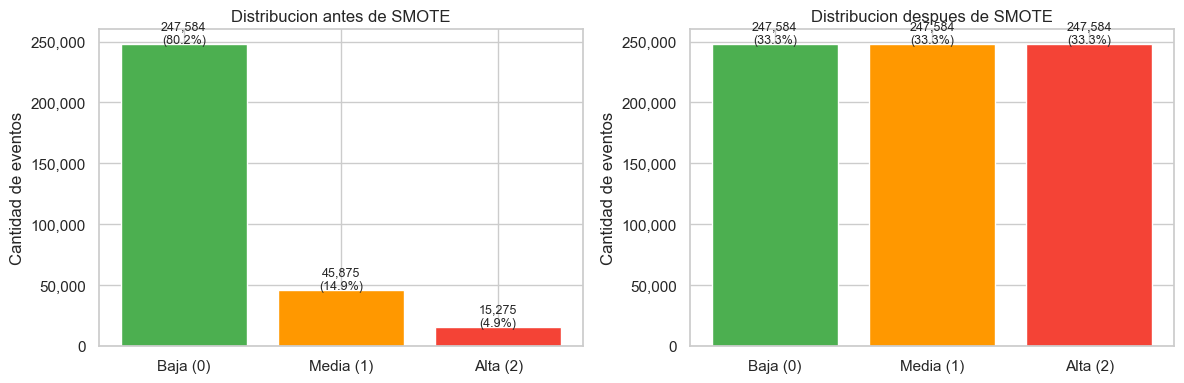

In [171]:
# Visualizacion del balance antes y despues
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

etiquetas = ['Baja (0)', 'Media (1)', 'Alta (2)']
colores   = ['#4CAF50', '#FF9800', '#f44336']

# Antes
conteo_antes = y_train.value_counts().sort_index()
axes[0].bar(etiquetas, conteo_antes.values, color=colores, edgecolor='white')
axes[0].set_title('Distribucion antes de SMOTE', fontsize=12)
axes[0].set_ylabel('Cantidad de eventos')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(conteo_antes.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(y_train)*100:.1f}%)',
                 ha='center', fontsize=9)

# Despues
conteo_despues = pd.Series(y_train_bal).value_counts().sort_index()
axes[1].bar(etiquetas, conteo_despues.values, color=colores, edgecolor='white')
axes[1].set_title('Distribucion despues de SMOTE', fontsize=12)
axes[1].set_ylabel('Cantidad de eventos')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(conteo_despues.values):
    axes[1].text(i, v + 1000, f'{v:,}\n({v/len(y_train_bal)*100:.1f}%)',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Reducción de Dimensionalidad

### 5.1 Selección de features — Métodos de filtro

Se evalúan las relaciones entre variables para identificar features poco
informativos o redundantes, usando tres criterios:

- **Varianza**: features con varianza cercana a cero no aportan información
  discriminativa y pueden eliminarse.
- **Correlación entre features**: features muy correlacionados entre sí son
  redundantes — aportan la misma información al modelo.
- **Correlación con el target**: se usa el estadístico F de ANOVA para medir
  cuánto varía cada feature entre las distintas clases de `intensity`.

In [172]:
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance

cols_binarias = [col for col in X_train_bal.columns 
                 if set(X_train_bal[col].dropna().unique()).issubset({0,1})]

cols_continuas = [col for col in X_train_bal.columns if col not in cols_binarias]

varianzas = pd.Series(X_train_bal[cols_continuas].var(),
                      name='Varianza').sort_values()

print('=== Filtro 1: Varianza ===')
print(varianzas.round(4).to_string())
print()
umbral_var = 0.01
cols_baja_varianza = varianzas[varianzas < umbral_var].index.tolist()
print(f'Features con varianza < {umbral_var}: {cols_baja_varianza}')

=== Filtro 1: Varianza ===
month_cos            0.4875
month_sin            0.4925
side_a_freq          0.8826
country_freq         0.9093
side_b_freq          0.9340
adm_1_freq           1.0203
year                 1.1358
adm_2_freq           1.1478
where_prec           1.1688
number_of_sources    1.6827
event_clarity        1.8054
date_prec            1.9888
event_duration       2.1646

Features con varianza < 0.01: []


In [173]:
print(cols_continuas)

['year', 'where_prec', 'date_prec', 'event_clarity', 'number_of_sources', 'event_duration', 'month_sin', 'month_cos', 'country_freq', 'side_a_freq', 'side_b_freq', 'adm_1_freq', 'adm_2_freq']


In [174]:
print(cols_binarias)

['adm1_missing_flag', 'adm2_missing_flag', 'side_a_is_state', 'side_b_is_state', 'is_multi_day_event', 'is_exact_date', 'is_precise_location', 'region_Americas', 'region_Asia', 'region_Europe', 'region_Middle East', 'type_of_violence_2', 'type_of_violence_3']


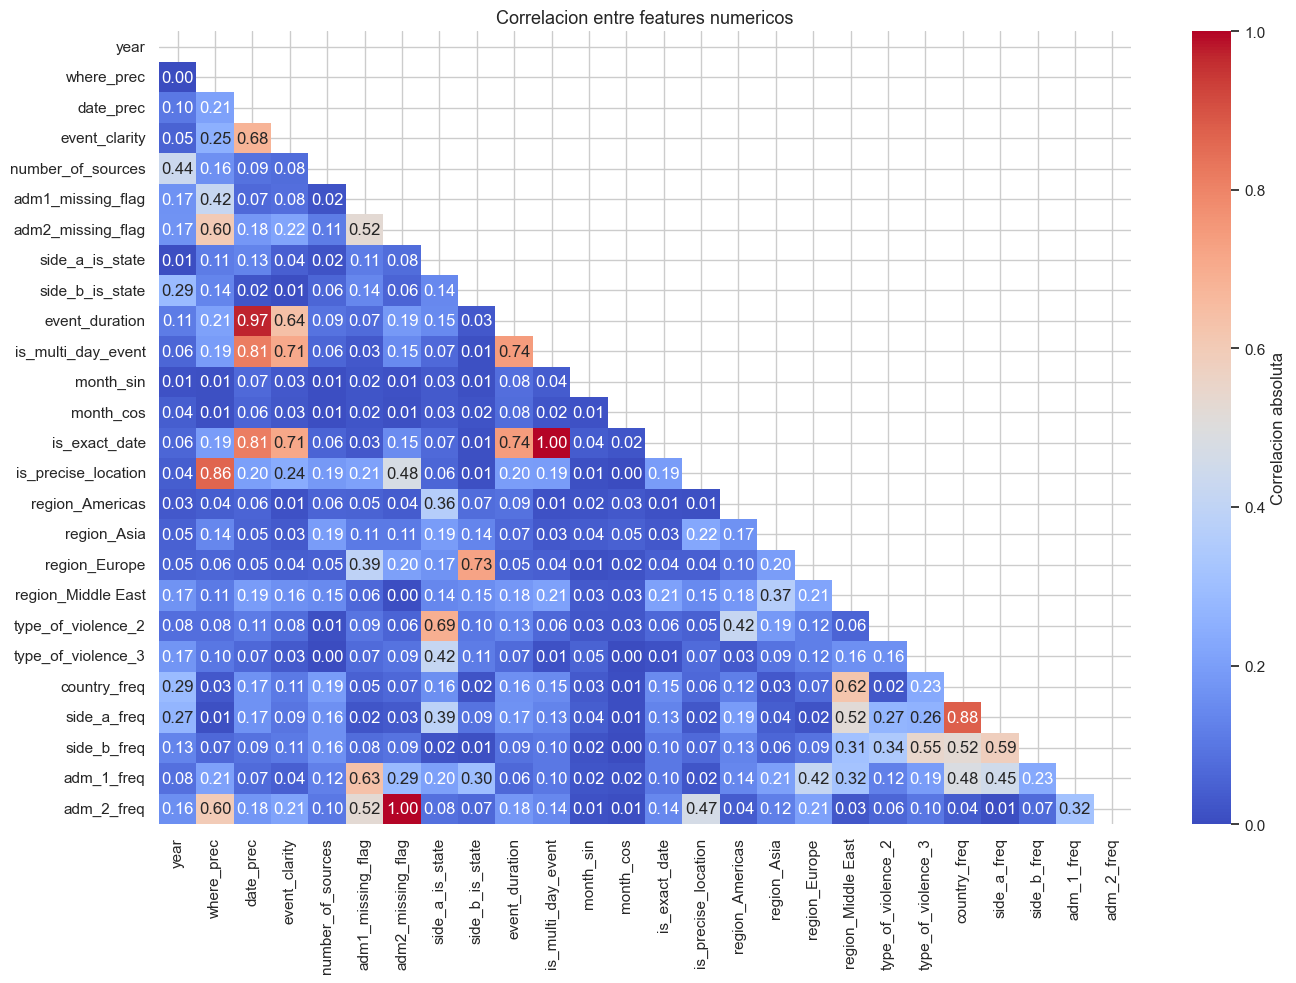

Pares con correlacion > 0.8:
  where_prec — is_precise_location: 0.864
  date_prec — event_duration: 0.971
  date_prec — is_multi_day_event: 0.814
  date_prec — is_exact_date: 0.813
  adm2_missing_flag — adm_2_freq: 0.998
  is_multi_day_event — is_exact_date: 0.998
  country_freq — side_a_freq: 0.878


In [175]:
# --- Filtro 2: Correlacion entre features ---
X_bal_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
corr_matrix = X_bal_df.corr().abs()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Correlacion absoluta'})
ax.set_title('Correlacion entre features numericos', fontsize=13)
#ax.grid(False)
plt.tight_layout()
plt.show()

# Detectar pares con correlacion > 0.8
umbral_corr = 0.8
pares_correlacionados = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > umbral_corr:
            pares_correlacionados.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print(f'Pares con correlacion > {umbral_corr}:')
if pares_correlacionados:
    for a, b, v in pares_correlacionados:
        print(f'  {a} — {b}: {v}')
else:
    print('  Ninguno encontrado.')

=== Resultados de filtros por metodo ===

ANOVA (features numericos continuos):
          Feature Metodo    Score  p-value
   event_duration  ANOVA 32304.98      0.0
             year  ANOVA  7457.43      0.0
number_of_sources  ANOVA  4715.09      0.0
        month_sin  ANOVA   285.82      0.0
        month_cos  ANOVA    99.74      0.0

Kruskal-Wallis (features ordinales):
      Feature         Metodo    Score  p-value
    date_prec Kruskal-Wallis 56829.74   0.0000
event_clarity Kruskal-Wallis 50082.39   0.0000
 country_freq Kruskal-Wallis 25532.52   0.0000
  side_a_freq Kruskal-Wallis 18219.77   0.0000
  side_b_freq Kruskal-Wallis 12828.83   0.0000
   adm_1_freq Kruskal-Wallis  8465.19   0.0000
   where_prec Kruskal-Wallis  4060.14   0.0000
   adm_2_freq Kruskal-Wallis    12.05   0.0024

Chi-cuadrado (features binarios/categoricos):
            Feature       Metodo    Score  p-value
 is_multi_day_event Chi-cuadrado 38511.99      0.0
    region_Americas Chi-cuadrado 23816.09      0.0
 

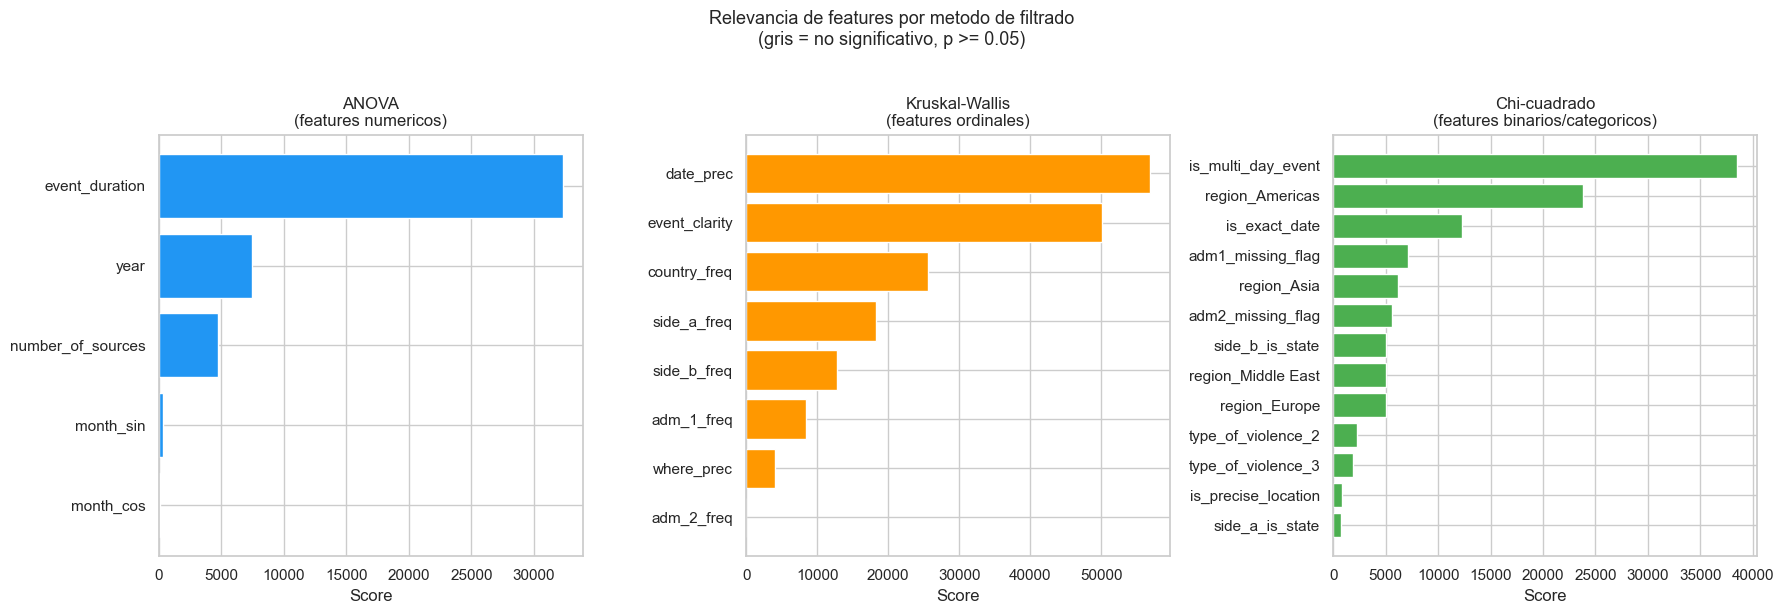


Todos los features son estadisticamente significativos (p < 0.05).


In [176]:
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from scipy.stats import kruskal

X_bal_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_bal_series = pd.Series(y_train_bal)

# --- Features numericos continuos → ANOVA ---
cols_anova = ['year', 'number_of_sources', 'event_duration',
              'month_sin', 'month_cos']

f_scores, p_values = f_classif(X_bal_df[cols_anova], y_bal_series)
df_anova = pd.DataFrame({
    'Feature'  : cols_anova,
    'Metodo'   : 'ANOVA',
    'Score'    : f_scores.round(2),
    'p-value'  : p_values.round(4)
}).sort_values('Score', ascending=False)

# --- Features ordinales → Kruskal-Wallis ---
cols_kruskal = ['where_prec', 'date_prec', 'event_clarity', 'country_freq',
              'side_a_freq', 'side_b_freq', 'adm_1_freq', 'adm_2_freq']

kruskal_results = []
for col in cols_kruskal:
    grupos = [X_bal_df[col][y_bal_series == c].values for c in sorted(y_bal_series.unique())]
    stat, p = kruskal(*grupos)
    kruskal_results.append({'Feature': col, 'Metodo': 'Kruskal-Wallis',
                            'Score': round(stat, 2), 'p-value': round(p, 4)})
df_kruskal = pd.DataFrame(kruskal_results).sort_values('Score', ascending=False)

# --- Features binarios/categoricos → Chi-cuadrado ---
# Chi2 requiere valores no negativos
X_chi2 = X_bal_df[cols_binarias].clip(lower=0)
chi2_scores, chi2_pvalues = chi2(X_chi2, y_bal_series)
df_chi2 = pd.DataFrame({
    'Feature' : cols_binarias,
    'Metodo'  : 'Chi-cuadrado',
    'Score'   : chi2_scores.round(2),
    'p-value' : chi2_pvalues.round(4)
}).sort_values('Score', ascending=False)

# --- Resumen combinado ---
df_filtros = pd.concat([df_anova, df_kruskal, df_chi2], ignore_index=True)
print('=== Resultados de filtros por metodo ===')
print()
print('ANOVA (features numericos continuos):')
print(df_anova.to_string(index=False))
print()
print('Kruskal-Wallis (features ordinales):')
print(df_kruskal.to_string(index=False))
print()
print('Chi-cuadrado (features binarios/categoricos):')
print(df_chi2.to_string(index=False))

# --- Visualizacion ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colores = {'ANOVA': '#2196F3', 'Kruskal-Wallis': '#FF9800', 'Chi-cuadrado': '#4CAF50'}

for ax, (df_plot, titulo) in zip(axes, [
    (df_anova,   'ANOVA\n(features numericos)'),
    (df_kruskal, 'Kruskal-Wallis\n(features ordinales)'),
    (df_chi2,    'Chi-cuadrado\n(features binarios/categoricos)')
]):
    metodo = df_plot['Metodo'].iloc[0]
    bars = ax.barh(df_plot['Feature'], df_plot['Score'],
                   color=[colores[metodo] if p < 0.05 else '#BDBDBD'
                          for p in df_plot['p-value']],
                   edgecolor='white')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Score')
    ax.invert_yaxis()

fig.suptitle('Relevancia de features por metodo de filtrado\n(gris = no significativo, p >= 0.05)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Features no significativos ---
no_sig = df_filtros[df_filtros['p-value'] >= 0.05]
if len(no_sig) > 0:
    print('\nFeatures no significativos (p >= 0.05):')
    print(no_sig[['Feature', 'Metodo', 'p-value']].to_string(index=False))
else:
    print('\nTodos los features son estadisticamente significativos (p < 0.05).')

### 5.2 Extracción de features — PCA

Se aplica **Análisis de Componentes Principales (PCA)** sobre los features
numéricos escalados del train set balanceado.

El PCA transforma las variables originales en **componentes principales** —
combinaciones lineales ortogonales que maximizan la varianza explicada.
Se entrena exclusivamente sobre el train set y se aplica a ambos conjuntos.


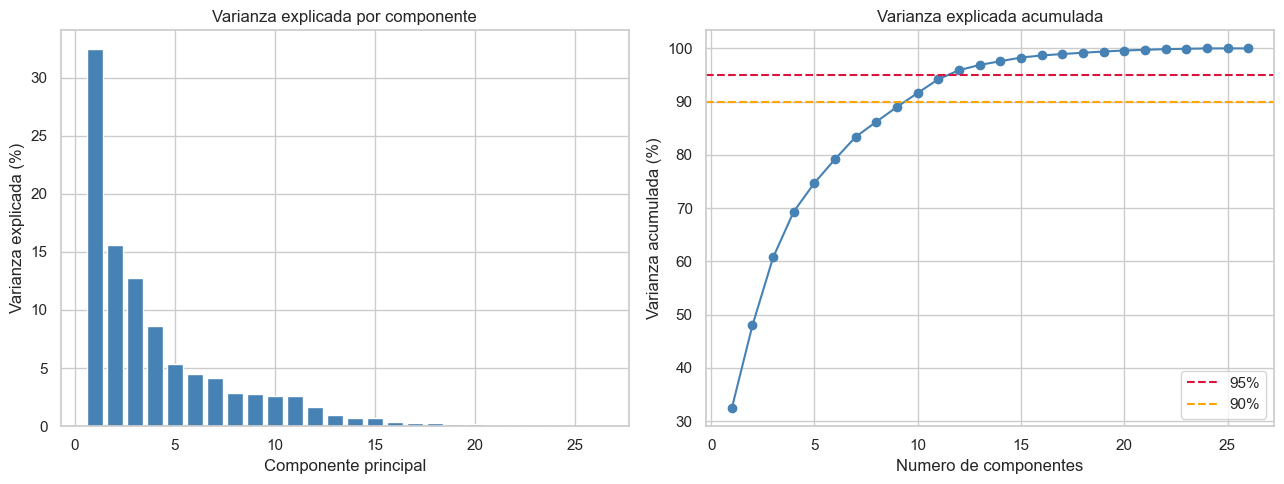

Componentes para explicar el 90% de la varianza: 10
Componentes para explicar el 95% de la varianza: 12


In [177]:
from sklearn.decomposition import PCA

# Usamos todos los features numericos para el PCA
X_pca_input = X_bal_df.values
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_input)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

# Grafico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Varianza explicada por componente', fontsize=12)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acum) + 1),
             varianza_acum * 100, marker='o', color='steelblue')
axes[1].axhline(y=95, color='crimson', linestyle='--', label='95%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90%')
axes[1].set_title('Varianza explicada acumulada', fontsize=12)
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

n_95 = np.argmax(varianza_acum >= 0.95) + 1
n_90 = np.argmax(varianza_acum >= 0.90) + 1
print(f'Componentes para explicar el 90% de la varianza: {n_90}')
print(f'Componentes para explicar el 95% de la varianza: {n_95}')
#print(f'Total de features originales: {len(cols_numericas_p5)}')

Shape train antes de PCA : (742752, 26)
Shape train despues de PCA: (742752, 12)
Reduccion: 26 -> 12 dimensiones

Contribucion de cada feature a las primeras 3 componentes principales:
                       PC1    PC2    PC3
year                -0.091  0.312 -0.231
where_prec           0.160  0.120  0.503
date_prec            0.558  0.111 -0.168
event_clarity        0.447  0.127 -0.044
number_of_sources   -0.114  0.394 -0.419
adm1_missing_flag    0.015  0.028  0.092
adm2_missing_flag    0.056  0.039  0.203
side_a_is_state     -0.023  0.047  0.064
side_b_is_state     -0.003  0.028  0.015
event_duration       0.575  0.112 -0.167
is_multi_day_event   0.145  0.029 -0.045
month_sin            0.020 -0.006 -0.024
month_cos            0.016  0.016 -0.018
is_exact_date       -0.145 -0.029  0.045
is_precise_location -0.066 -0.022 -0.179
region_Americas      0.008 -0.025 -0.016
region_Asia         -0.001 -0.040  0.023
region_Europe       -0.004  0.019  0.041
region_Middle East  -0.053  0.131  0

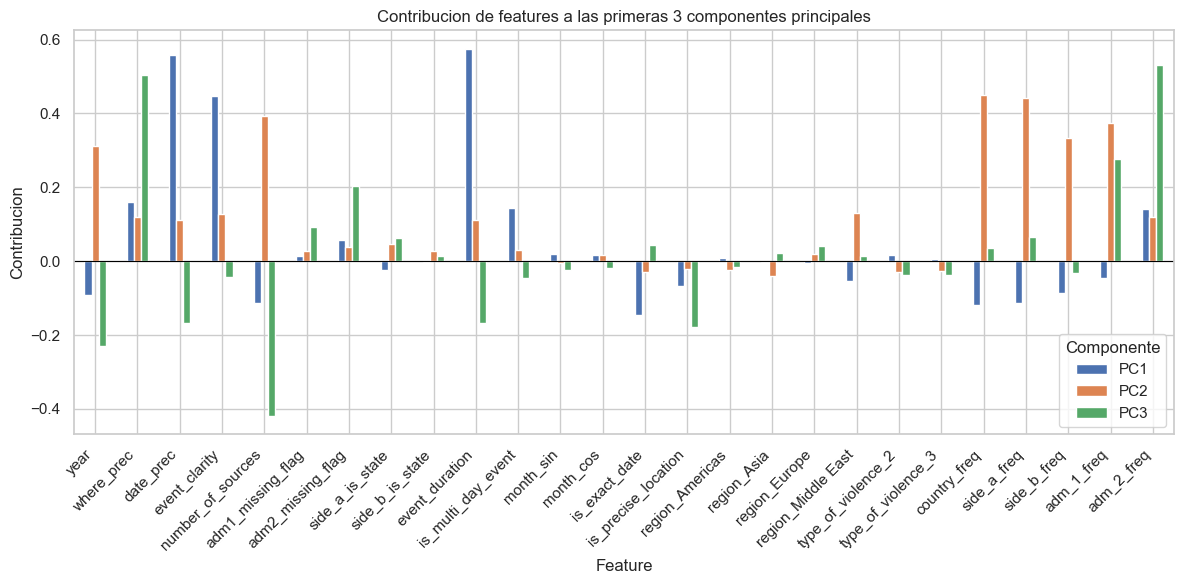

In [178]:
# Aplicar PCA con n componentes para 95% de varianza
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_bal_df)
X_test_pca  = pca.transform(X_test_df)

print(f'Shape train antes de PCA : {X_bal_df.shape}')
print(f'Shape train despues de PCA: {X_train_pca.shape}')
print(f'Reduccion: {X_bal_df.shape[1]} -> {X_train_pca.shape[1]} dimensiones')
print()

# Contribucion de cada feature a las primeras 3 componentes
componentes_df = pd.DataFrame(
    pca.components_[:3].T,
    index=X_bal_df.columns,
    columns=[f'PC{i+1}' for i in range(min(3, n_95))]
).round(3)

print('Contribucion de cada feature a las primeras 3 componentes principales:')
print(componentes_df.to_string())

# Visualizacion de contribuciones
fig, ax = plt.subplots(figsize=(12, 6))
componentes_df.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Contribucion de features a las primeras 3 componentes principales', fontsize=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Contribucion')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend(title='Componente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [179]:
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"PC{i+1}: {var:.2%}")

PC1: 32.43%
PC2: 15.57%
PC3: 12.74%
PC4: 8.62%
PC5: 5.36%


### 5.3 Análisis de ventajas y desventajas de la reducción

#### Selección de features (filtros)

Los métodos de filtrado aplicados (ANOVA, Kruskal-Wallis y Chi-cuadrado) permitieron
identificar los features más relevantes para predecir `intensity`:

- **Más relevantes:** `event_duration`, `date_prec`, `event_clarity`, `is_multi_day_event`, `region_Americas`, `is_exact_date`
- **Menos relevantes:** `month_sin`, `month_cos`, `is_exact_date`, `is_precise_location`, `side_a_is_state`, `number_of_sources`

| Ventajas | Desventajas |
|---|---|
| Mantiene la interpretabilidad de los features | Puede eliminar features con baja varianza individual pero alta información combinada |
| Reduce ruido y redundancia | Los umbrales de corte son arbitrarios |
| Cada método es apropiado para el tipo de variable | No considera interacciones entre variables |

#### PCA

El PCA aplicado sobre los 26 features numéricos mostró los siguientes resultados:

- La **PC1 explica el 31%** de la varianza por sí sola, dominada por `date_prec` y
  `event_clarity` — captura la calidad del registro del evento.
- La **PC2 explica el 15%**, dominada por `number_of_sources` — captura la cobertura mediática.
- La **PC3 explica el 12%**, dominada por `where_prec` — captura la precisión geográfica.
- Se necesitan **12 componentes** para explicar el 95% de la varianza, frente a los
  26 features originales — una reducción del 60% en dimensionalidad.

| Ventajas | Desventajas |
|---|---|
| Reduce de 26 a 12 dimensiones conservando el 95% de la varianza | Las componentes no tienen interpretación directa |
| Elimina multicolinealidad (ej: `event_duration` e `is_multi_day_event` con correlación 0.97) | Dificulta explicar qué factores predicen la intensidad |
| Mejora eficiencia computacional | Sensible a la escala — requiere escalado previo |
| Útil cuando hay features muy correlacionados | Asume relaciones lineales entre variables |

#### Conclusión

Para este dataset, la **selección de features por filtros** es preferible como paso
principal ya que preserva la interpretabilidad — en un contexto de análisis de
conflictos armados, entender **qué factores predicen la intensidad** es tan valioso
como la predicción en sí.

El PCA es útil como complemento para reducir dimensionalidad y eliminar redundancia
(como la alta correlación entre `event_duration` e `is_multi_day_event`), pero no
se recomienda como reemplazo de los features originales para el modelo final dado
que pierde la capacidad de explicar qué variables son determinantes.